In [1]:
import torch
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import rbf_kernel
import deep_sdf.workspace as ws
import networks.sdf_vae as vae
import json
import time
from scipy.stats import pearsonr
from scipy.spatial.distance import pdist, squareform
from sklearn.neighbors import NearestNeighbors

# Set up paths
experiment_directory = "examples/hippocampus_MS"
supervised_path = os.path.join(experiment_directory, "all_supervised_hippo_contrastive_with_pretrained_model")
unsupervised_path = os.path.join(experiment_directory, "all_unsupervised_hippo_saved_models")

# Load specs
specs = ws.load_experiment_specifications(experiment_directory)
data_source = specs["DataSource"]
data_source_mesh = specs["DataSourceMesh"]
train_split_file = specs["TrainSplit"]

# Model parameters
latent_size = specs["CodeLength"]
num_samp_per_scene = specs["SamplesPerScene"]
decoder_specs = specs["NetworkSpecs"]
kl_div_loss = False

print(f"Latent size: {latent_size}")
print(f"Supervised model path: {supervised_path}")
print(f"Unsupervised model path: {unsupervised_path}")

Latent size: 16
Supervised model path: examples/hippocampus_MS/all_supervised_hippo_contrastive_with_pretrained_model
Unsupervised model path: examples/hippocampus_MS/all_unsupervised_hippo_saved_models


In [2]:
def load_model_and_extract_latents(model_path, model_name):
    """Load a model and extract latent variables for all training data"""
    
    # Load model
    decoder = vae.SDFVAE(latent_size, num_samp_per_scene, decoder_specs, kl_div_loss).cuda()
    
    model_file = os.path.join(model_path, "ModelParameters", "latest.pth")
    if os.path.exists(model_file):
        print(f"Loading {model_name} model from: {model_file}")
        saved_model_state = torch.load(model_file)
        decoder.load_state_dict(saved_model_state["model_state_dict"])
        decoder.eval()
        print(f"{model_name} model loaded successfully!")
    else:
        raise FileNotFoundError(f"Model file not found: {model_file}")
    
    # Load training data
    with open(train_split_file, "r") as f:
        train_split = json.load(f)
    
    # Get training filenames
    import deep_sdf.data as data
    eval_train_filenames = data.get_instance_filenames(data_source, train_split)
    
    # Load labels
    labels_path = os.path.join(data_source, "labels.pt")
    all_labels = torch.load(labels_path)
    
    # Extract latents for each training sample
    all_latents = []
    all_ages = []
    all_diseases = []
    filenames = []
    
    print(f"Extracting latents from {len(eval_train_filenames)} training samples...")
    
    with torch.no_grad():
        for i, train_fname in enumerate(eval_train_filenames):
            if i % 50 == 0:
                print(f"Processing {i}/{len(eval_train_filenames)}")
                
            save_name = os.path.basename(train_fname).split(".npz")[0]
            mesh_path = os.path.join(data_source_mesh, save_name + ".obj")
            
            # Get surface points
            surface_points = data.get_surface_points(mesh_path)
            surface_points = torch.from_numpy(surface_points).unsqueeze(0).cuda()
            
            # Extract latent using encoder
            if kl_div_loss:
                mu, logvar = decoder.encoder(surface_points)
                latent = mu
            else:
                latent = decoder.encoder(surface_points)
            
            all_latents.append(latent.cpu().numpy().squeeze())
            
            # Get labels
            if save_name in all_labels:
                label = all_labels[save_name]
                all_ages.append(float(label[0].item()))
                all_diseases.append(int(label[1].item()))
            else:
                print(f"Warning: No label found for {save_name}")
                all_ages.append(0.0)
                all_diseases.append(0)
            
            filenames.append(save_name)
    
    latents_array = np.stack(all_latents, axis=0)
    print(f"Extracted latents shape: {latents_array.shape}")
    
    return {
        'latents': latents_array,
        'ages': np.array(all_ages),
        'diseases': np.array(all_diseases),
        'filenames': filenames,
        'decoder': decoder
    }

# Extract latents from both models
print("="*60)
print("EXTRACTING LATENTS FROM BOTH MODELS")
print("="*60)

unsupervised_data = load_model_and_extract_latents(unsupervised_path, "Unsupervised")
supervised_data = load_model_and_extract_latents(supervised_path, "Supervised")

# Save the extracted latents
save_dir = os.path.join(experiment_directory, "latent_comparison_contrastive")
os.makedirs(save_dir, exist_ok=True)

np.save(os.path.join(save_dir, "unsupervised_latents.npy"), unsupervised_data['latents'])
np.save(os.path.join(save_dir, "supervised_latents.npy"), supervised_data['latents'])
np.save(os.path.join(save_dir, "ages.npy"), unsupervised_data['ages'])
np.save(os.path.join(save_dir, "diseases.npy"), unsupervised_data['diseases'])

print(f"Saved latents to: {save_dir}")
print(f"Unsupervised latents shape: {unsupervised_data['latents'].shape}")
print(f"Supervised latents shape: {supervised_data['latents'].shape}")

EXTRACTING LATENTS FROM BOTH MODELS
Loading Unsupervised model from: examples/hippocampus_MS/all_unsupervised_hippo_saved_models/ModelParameters/latest.pth
Unsupervised model loaded successfully!
Extracting latents from 196 training samples...
Processing 0/196
Processing 50/196
Processing 100/196
Processing 150/196
Extracted latents shape: (196, 16)
Loading Supervised model from: examples/hippocampus_MS/all_supervised_hippo_contrastive_with_pretrained_model/ModelParameters/latest.pth
Supervised model loaded successfully!
Extracting latents from 196 training samples...
Processing 0/196
Processing 50/196
Processing 100/196
Processing 150/196
Extracted latents shape: (196, 16)
Saved latents to: examples/hippocampus_MS/latent_comparison_contrastive
Unsupervised latents shape: (196, 16)
Supervised latents shape: (196, 16)


BASIC STATISTICS AND CORRELATION ANALYSIS
Data shapes:
  Unsupervised latents: (196, 16)
  Supervised latents: (196, 16)
  Ages: (196,), range: [0.3, 0.8]
  Diseases: (196,), unique: [0 1]

Unsupervised Model - Factor Correlations:
----------------------------------------

Best correlations:
  Age: Dim 0 (r=-0.344)
  Disease: Dim 7 (r=0.183)

Supervised Model - Factor Correlations:
----------------------------------------

Best correlations:
  Age: Dim 1 (r=-0.870)
  Disease: Dim 0 (r=-0.375)


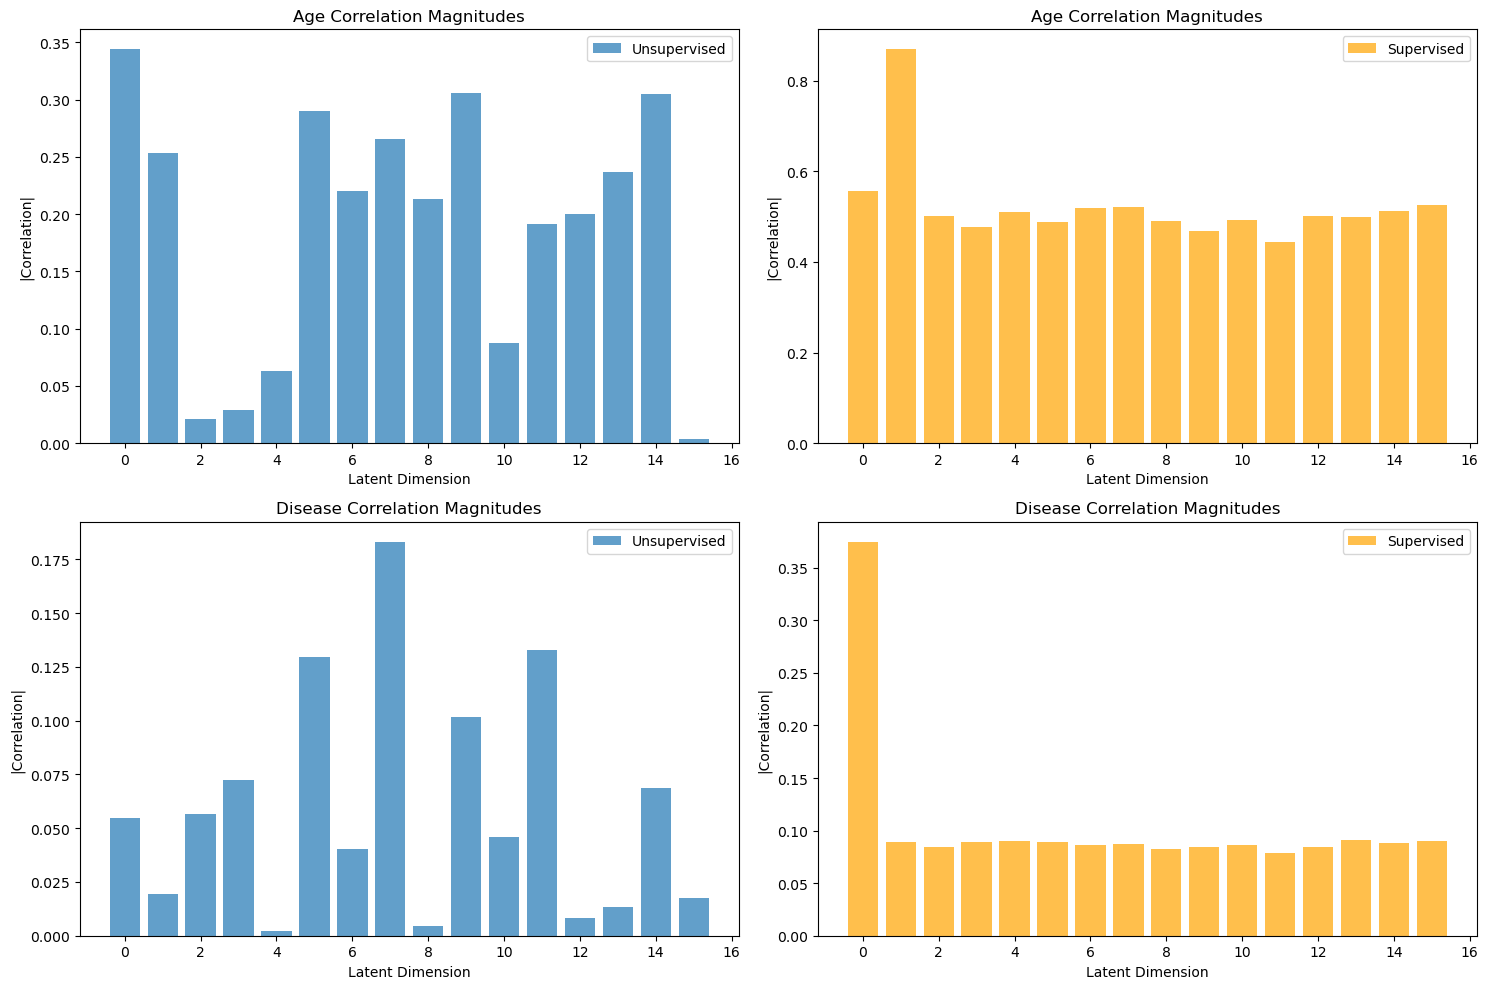


Summary Statistics:
Unsupervised - Mean |age corr|: 0.189, Max: 0.344
Supervised   - Mean |age corr|: 0.524, Max: 0.870
Unsupervised - Mean |disease corr|: 0.059, Max: 0.183
Supervised   - Mean |disease corr|: 0.105, Max: 0.375


In [4]:
# Get the data
Z_u = unsupervised_data['latents']  # Unsupervised latents (N, 16)
Z_s = supervised_data['latents']    # Supervised latents (N, 16)
ages = unsupervised_data['ages']
diseases = unsupervised_data['diseases']

print("="*60)
print("BASIC STATISTICS AND CORRELATION ANALYSIS")
print("="*60)

# Basic statistics
print(f"Data shapes:")
print(f"  Unsupervised latents: {Z_u.shape}")
print(f"  Supervised latents: {Z_s.shape}")
print(f"  Ages: {ages.shape}, range: [{ages.min():.1f}, {ages.max():.1f}]")
print(f"  Diseases: {diseases.shape}, unique: {np.unique(diseases)}")

# Calculate correlations with factors for both models
def calculate_factor_correlations(latents, ages, diseases, model_name):
    print(f"\n{model_name} Model - Factor Correlations:")
    print("-" * 40)
    
    age_corrs = []
    disease_corrs = []
    
    for dim in range(latents.shape[1]):
        age_corr, _ = pearsonr(latents[:, dim], ages)
        disease_corr, _ = pearsonr(latents[:, dim], diseases)
        
        age_corrs.append(age_corr)
        disease_corrs.append(disease_corr)
        
        #print(f"Dim {dim:2d}: Age={age_corr:6.3f}, Disease={disease_corr:6.3f}")
    
    # Find best dimensions
    best_age_dim = np.argmax(np.abs(age_corrs))
    best_disease_dim = np.argmax(np.abs(disease_corrs))
    
    print(f"\nBest correlations:")
    print(f"  Age: Dim {best_age_dim} (r={age_corrs[best_age_dim]:.3f})")
    print(f"  Disease: Dim {best_disease_dim} (r={disease_corrs[best_disease_dim]:.3f})")
    
    return np.array(age_corrs), np.array(disease_corrs)

unsup_age_corrs, unsup_disease_corrs = calculate_factor_correlations(Z_u, ages, diseases, "Unsupervised")
sup_age_corrs, sup_disease_corrs = calculate_factor_correlations(Z_s, ages, diseases, "Supervised")

# Visualize correlations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Age correlations
axes[0, 0].bar(range(16), np.abs(unsup_age_corrs), alpha=0.7, label='Unsupervised')
axes[0, 0].set_title('Age Correlation Magnitudes')
axes[0, 0].set_xlabel('Latent Dimension')
axes[0, 0].set_ylabel('|Correlation|')
axes[0, 0].legend()

axes[0, 1].bar(range(16), np.abs(sup_age_corrs), alpha=0.7, label='Supervised', color='orange')
axes[0, 1].set_title('Age Correlation Magnitudes')
axes[0, 1].set_xlabel('Latent Dimension')
axes[0, 1].set_ylabel('|Correlation|')
axes[0, 1].legend()

# Disease correlations
axes[1, 0].bar(range(16), np.abs(unsup_disease_corrs), alpha=0.7, label='Unsupervised')
axes[1, 0].set_title('Disease Correlation Magnitudes')
axes[1, 0].set_xlabel('Latent Dimension')
axes[1, 0].set_ylabel('|Correlation|')
axes[1, 0].legend()

axes[1, 1].bar(range(16), np.abs(sup_disease_corrs), alpha=0.7, label='Supervised', color='orange')
axes[1, 1].set_title('Disease Correlation Magnitudes')
axes[1, 1].set_xlabel('Latent Dimension')
axes[1, 1].set_ylabel('|Correlation|')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig(os.path.join(save_dir, "factor_correlations_comparison.png"), dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics
print(f"\nSummary Statistics:")
print(f"Unsupervised - Mean |age corr|: {np.mean(np.abs(unsup_age_corrs)):.3f}, Max: {np.max(np.abs(unsup_age_corrs)):.3f}")
print(f"Supervised   - Mean |age corr|: {np.mean(np.abs(sup_age_corrs)):.3f}, Max: {np.max(np.abs(sup_age_corrs)):.3f}")
print(f"Unsupervised - Mean |disease corr|: {np.mean(np.abs(unsup_disease_corrs)):.3f}, Max: {np.max(np.abs(unsup_disease_corrs)):.3f}")
print(f"Supervised   - Mean |disease corr|: {np.mean(np.abs(sup_disease_corrs)):.3f}, Max: {np.max(np.abs(sup_disease_corrs)):.3f}")


WHITENING AND PREPROCESSING
Original shapes: Z_u=(196, 16), Z_s=(196, 16)
Whitened shapes: Z_u_w=(196, 16), Z_s_w=(196, 16)

Unsupervised whitening check:
  Mean magnitude: 0.000004 (should be ~0)
  Covariance trace: 15.946 (should be ~16)
  Off-diagonal magnitude: 0.026642 (should be ~0)

Supervised whitening check:
  Mean magnitude: 0.000040 (should be ~0)
  Covariance trace: 16.000 (should be ~16)
  Off-diagonal magnitude: 0.000180 (should be ~0)


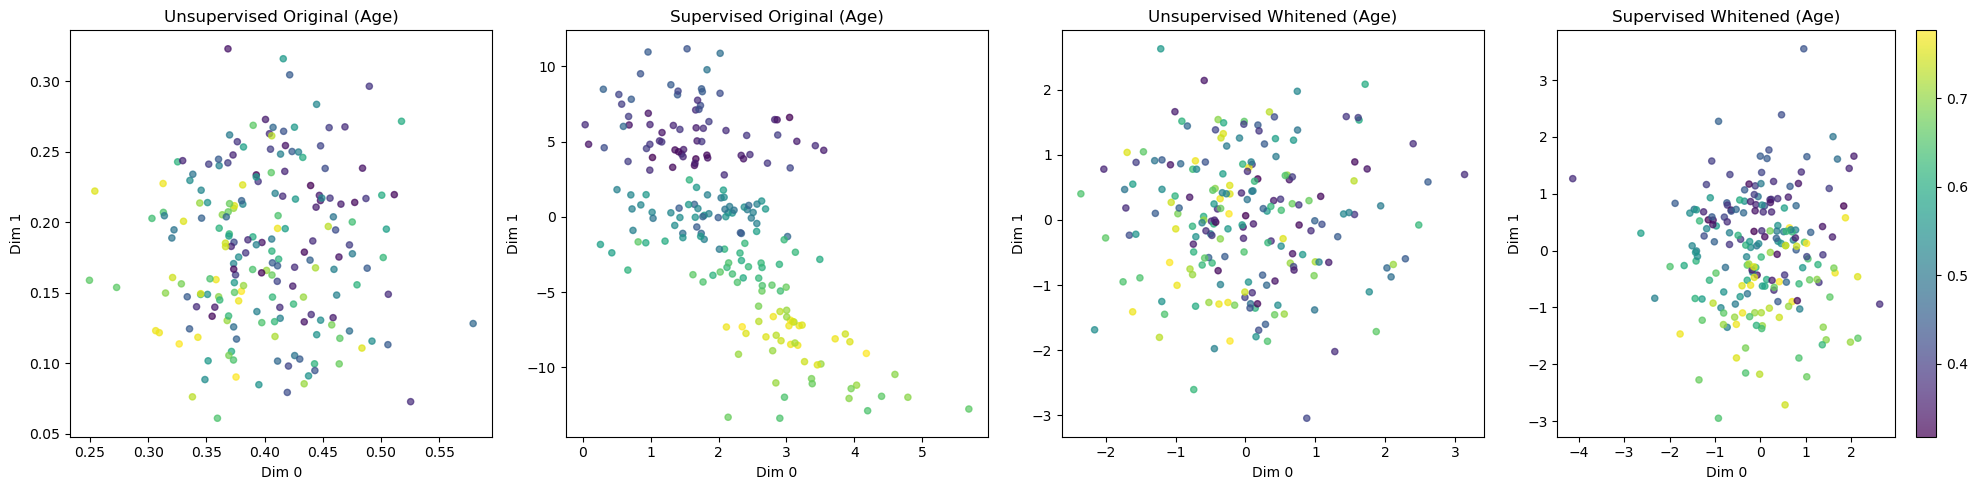

In [5]:
def whiten(Z, eps=1e-6):
    """
    Z: (N,d) matrix of latents
    returns: Z_w (whitened), mean, whitening matrix W (so Z_w = (Z - mean) @ W)
    """
    mu = Z.mean(axis=0, keepdims=True)          # (1,d)
    X  = Z - mu                                 # center
    C  = np.cov(X.T)                           # (d,d) covariance
    U, S, _ = np.linalg.svd(C + eps*np.eye(C.shape[0]))  # eigendecomp via SVD
    W = U @ np.diag(1.0 / np.sqrt(S)) @ U.T    # Σ^{-1/2}
    Z_w = X @ W
    return Z_w, mu, W

print("="*60)
print("WHITENING AND PREPROCESSING")
print("="*60)

# Apply whitening to both latent spaces
Z_u_w, mu_u, W_u = whiten(Z_u)
Z_s_w, mu_s, W_s = whiten(Z_s)

print(f"Original shapes: Z_u={Z_u.shape}, Z_s={Z_s.shape}")
print(f"Whitened shapes: Z_u_w={Z_u_w.shape}, Z_s_w={Z_s_w.shape}")

# Verify whitening worked
def check_whitening(Z_w, name):
    mean = np.mean(Z_w, axis=0)
    cov = np.cov(Z_w.T)
    
    print(f"\n{name} whitening check:")
    print(f"  Mean magnitude: {np.linalg.norm(mean):.6f} (should be ~0)")
    print(f"  Covariance trace: {np.trace(cov):.3f} (should be ~{Z_w.shape[1]})")
    print(f"  Off-diagonal magnitude: {np.linalg.norm(cov - np.eye(cov.shape[0])):.6f} (should be ~0)")

check_whitening(Z_u_w, "Unsupervised")
check_whitening(Z_s_w, "Supervised")

# Visualize covariance matrices before and after whitening
fig, axes = plt.subplots(1, 4, figsize=(20, 5))  # Changed figsize to be more appropriate for 1 row

# Scatter plots of first two dimensions before whitening
axes[0].scatter(Z_u[:, 0], Z_u[:, 1], c=ages, cmap='viridis', alpha=0.7, s=20)
axes[0].set_title('Unsupervised Original (Age)')
axes[0].set_xlabel('Dim 0')
axes[0].set_ylabel('Dim 1')

axes[1].scatter(Z_s[:, 0], Z_s[:, 1], c=ages, cmap='viridis', alpha=0.7, s=20)
axes[1].set_title('Supervised Original (Age)')
axes[1].set_xlabel('Dim 0')
axes[1].set_ylabel('Dim 1')

# Scatter plots of first two dimensions after whitening
axes[2].scatter(Z_u_w[:, 0], Z_u_w[:, 1], c=ages, cmap='viridis', alpha=0.7, s=20)
axes[2].set_title('Unsupervised Whitened (Age)')
axes[2].set_xlabel('Dim 0')
axes[2].set_ylabel('Dim 1')

sc = axes[3].scatter(Z_s_w[:, 0], Z_s_w[:, 1], c=ages, cmap='viridis', alpha=0.7, s=20)
axes[3].set_title('Supervised Whitened (Age)')
axes[3].set_xlabel('Dim 0')
axes[3].set_ylabel('Dim 1')
plt.colorbar(sc, ax=axes[3])

plt.tight_layout()
plt.savefig(os.path.join(save_dir, "whitening_visualization.png"), dpi=300, bbox_inches='tight')
plt.show()

ORTHOGONAL PROCRUSTES ANALYSIS
Procrustes rotation matrix W0 shape: (16, 16)
Orthogonality error ||W0^T W0 - I||_F: 0.000000
Relative alignment error: 0.9629
Per-sample alignment errors - Mean: 3.7150, Std: 0.9786


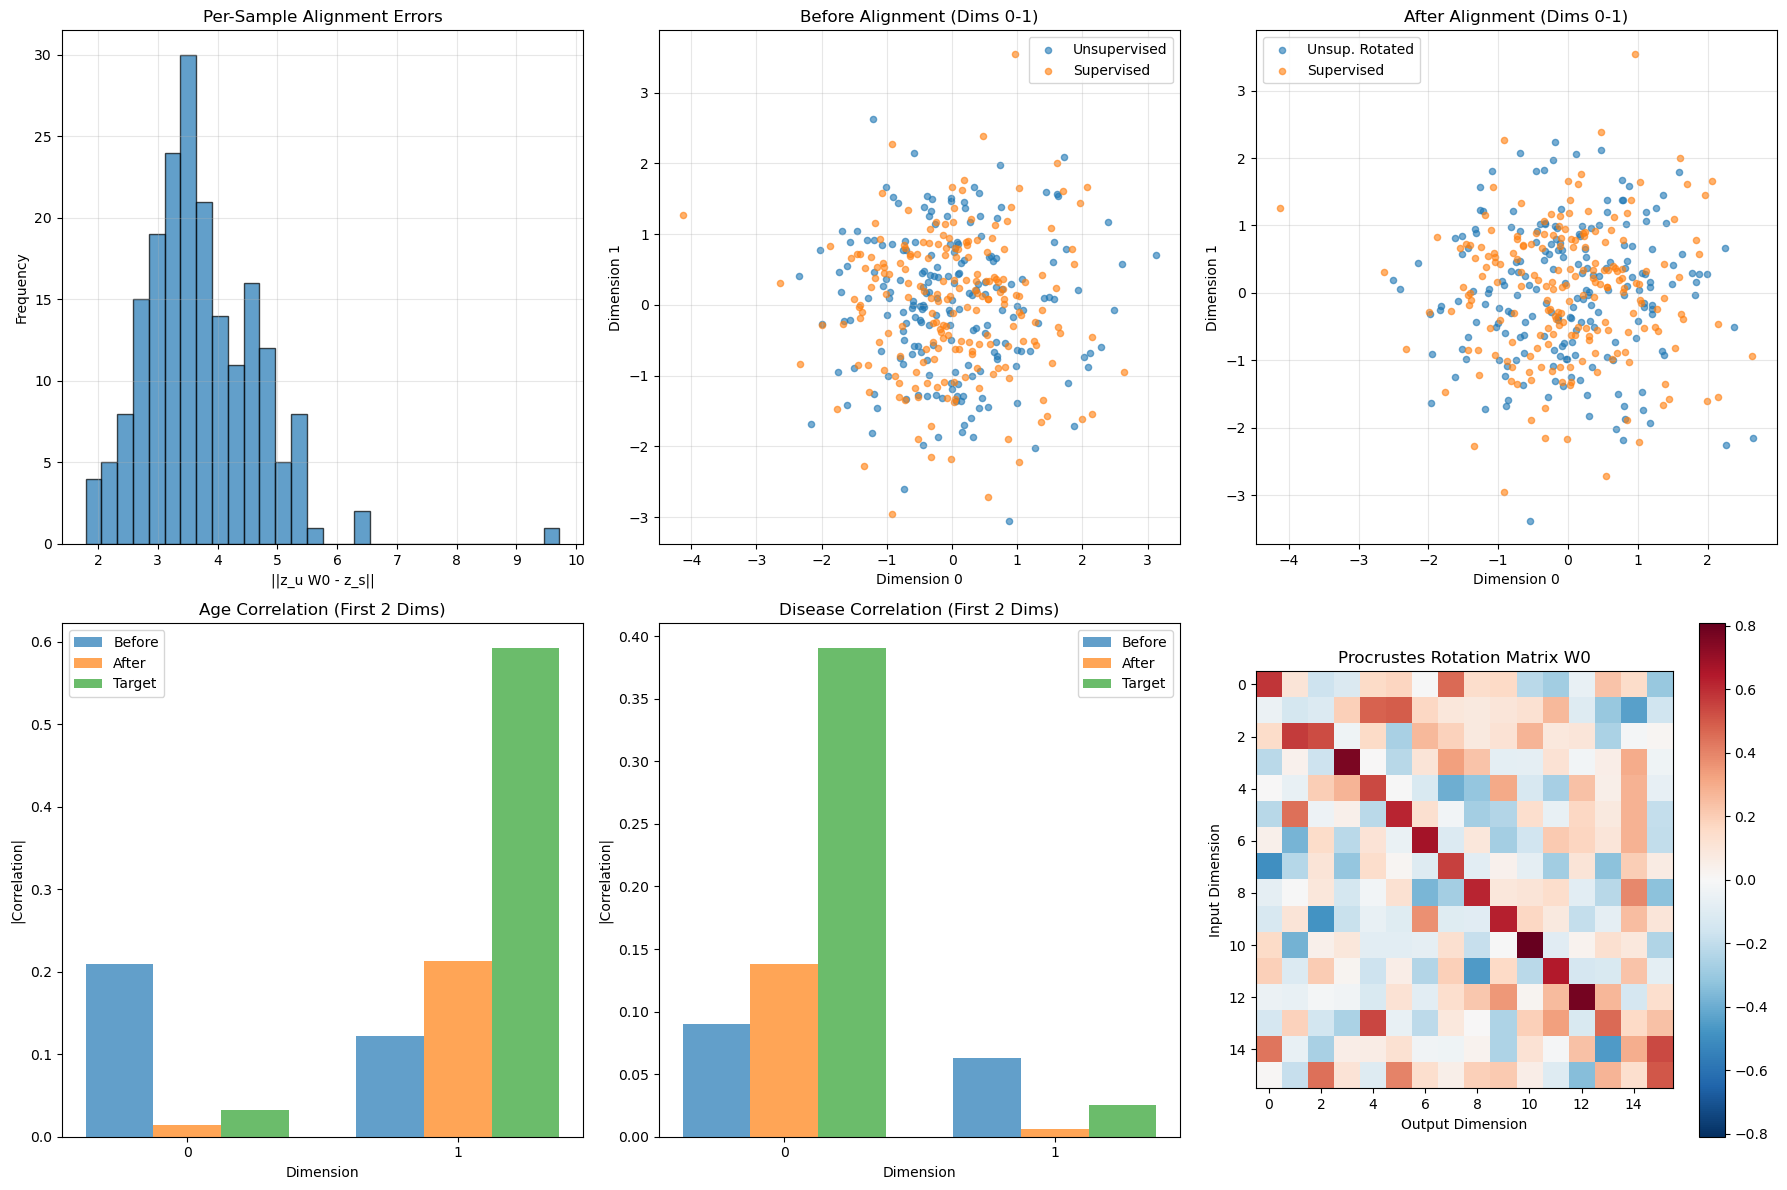


Correlation improvements (first 2 dimensions):
Age Dim 0: 0.210 → 0.015 (target: 0.033)
Age Dim 1: 0.122 → 0.213 (target: 0.593)
Disease Dim 0: 0.090 → 0.138 (target: 0.391)
Disease Dim 1: 0.063 → 0.006 (target: 0.025)


In [6]:
print("="*60)
print("ORTHOGONAL PROCRUSTES ANALYSIS")
print("="*60)

# Compute Orthogonal Procrustes solution
M = Z_u_w.T @ Z_s_w                           # (16,16)
U, _, Vt = np.linalg.svd(M, full_matrices=False)
W0 = U @ Vt                                   # best rotation

print(f"Procrustes rotation matrix W0 shape: {W0.shape}")

# Check orthogonality
orthogonality_error = np.linalg.norm(W0.T @ W0 - np.eye(16), 'fro')
print(f"Orthogonality error ||W0^T W0 - I||_F: {orthogonality_error:.6f}")

# Apply rotation
Z_u_rotated = Z_u_w @ W0

# Calculate alignment error
alignment_error = np.linalg.norm(Z_u_rotated - Z_s_w, 'fro') / np.linalg.norm(Z_s_w, 'fro')
print(f"Relative alignment error: {alignment_error:.4f}")

# Per-sample alignment errors
sample_errors = np.linalg.norm(Z_u_rotated - Z_s_w, axis=1)
print(f"Per-sample alignment errors - Mean: {np.mean(sample_errors):.4f}, Std: {np.std(sample_errors):.4f}")

# Visualize alignment results
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Histogram of per-sample errors
axes[0, 0].hist(sample_errors, bins=30, alpha=0.7, edgecolor='black')
axes[0, 0].set_title('Per-Sample Alignment Errors')
axes[0, 0].set_xlabel('||z_u W0 - z_s||')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].grid(True, alpha=0.3)

# Before alignment - first two dims
axes[0, 1].scatter(Z_u_w[:, 0], Z_u_w[:, 1], alpha=0.6, label='Unsupervised', s=20)
axes[0, 1].scatter(Z_s_w[:, 0], Z_s_w[:, 1], alpha=0.6, label='Supervised', s=20)
axes[0, 1].set_title('Before Alignment (Dims 0-1)')
axes[0, 1].set_xlabel('Dimension 0')
axes[0, 1].set_ylabel('Dimension 1')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# After alignment - first two dims
axes[0, 2].scatter(Z_u_rotated[:, 0], Z_u_rotated[:, 1], alpha=0.6, label='Unsup. Rotated', s=20)
axes[0, 2].scatter(Z_s_w[:, 0], Z_s_w[:, 1], alpha=0.6, label='Supervised', s=20)
axes[0, 2].set_title('After Alignment (Dims 0-1)')
axes[0, 2].set_xlabel('Dimension 0')
axes[0, 2].set_ylabel('Dimension 1')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# Factor correlation improvement
def compare_factor_correlations(Z_before, Z_after, Z_target, ages, diseases):
    """Compare factor correlations before and after alignment"""
    
    age_corr_before = [abs(pearsonr(Z_before[:, i], ages)[0]) for i in range(2)]
    age_corr_after = [abs(pearsonr(Z_after[:, i], ages)[0]) for i in range(2)]
    age_corr_target = [abs(pearsonr(Z_target[:, i], ages)[0]) for i in range(2)]
    
    disease_corr_before = [abs(pearsonr(Z_before[:, i], diseases)[0]) for i in range(2)]
    disease_corr_after = [abs(pearsonr(Z_after[:, i], diseases)[0]) for i in range(2)]
    disease_corr_target = [abs(pearsonr(Z_target[:, i], diseases)[0]) for i in range(2)]
    
    return {
        'age': {'before': age_corr_before, 'after': age_corr_after, 'target': age_corr_target},
        'disease': {'before': disease_corr_before, 'after': disease_corr_after, 'target': disease_corr_target}
    }

corr_comparison = compare_factor_correlations(Z_u_w, Z_u_rotated, Z_s_w, ages, diseases)

# Plot correlation improvements
x = np.arange(2)
width = 0.25

axes[1, 0].bar(x - width, corr_comparison['age']['before'], width, label='Before', alpha=0.7)
axes[1, 0].bar(x, corr_comparison['age']['after'], width, label='After', alpha=0.7)
axes[1, 0].bar(x + width, corr_comparison['age']['target'], width, label='Target', alpha=0.7)
axes[1, 0].set_title('Age Correlation (First 2 Dims)')
axes[1, 0].set_xlabel('Dimension')
axes[1, 0].set_ylabel('|Correlation|')
axes[1, 0].set_xticks(x)
axes[1, 0].legend()

axes[1, 1].bar(x - width, corr_comparison['disease']['before'], width, label='Before', alpha=0.7)
axes[1, 1].bar(x, corr_comparison['disease']['after'], width, label='After', alpha=0.7)
axes[1, 1].bar(x + width, corr_comparison['disease']['target'], width, label='Target', alpha=0.7)
axes[1, 1].set_title('Disease Correlation (First 2 Dims)')
axes[1, 1].set_xlabel('Dimension')
axes[1, 1].set_ylabel('|Correlation|')
axes[1, 1].set_xticks(x)
axes[1, 1].legend()

# Visualize the rotation matrix
vmax = np.abs(W0).max()
im = axes[1, 2].imshow(W0, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
axes[1, 2].set_title('Procrustes Rotation Matrix W0')
axes[1, 2].set_xlabel('Output Dimension')
axes[1, 2].set_ylabel('Input Dimension')
plt.colorbar(im, ax=axes[1, 2])

plt.tight_layout()
plt.savefig(os.path.join(save_dir, "procrustes_analysis.png"), dpi=300, bbox_inches='tight')
plt.show()

print(f"\nCorrelation improvements (first 2 dimensions):")
print(f"Age Dim 0: {corr_comparison['age']['before'][0]:.3f} → {corr_comparison['age']['after'][0]:.3f} (target: {corr_comparison['age']['target'][0]:.3f})")
print(f"Age Dim 1: {corr_comparison['age']['before'][1]:.3f} → {corr_comparison['age']['after'][1]:.3f} (target: {corr_comparison['age']['target'][1]:.3f})")
print(f"Disease Dim 0: {corr_comparison['disease']['before'][0]:.3f} → {corr_comparison['disease']['after'][0]:.3f} (target: {corr_comparison['disease']['target'][0]:.3f})")
print(f"Disease Dim 1: {corr_comparison['disease']['before'][1]:.3f} → {corr_comparison['disease']['after'][1]:.3f} (target: {corr_comparison['disease']['target'][1]:.3f})")

TRAINING RESIDUAL MLP
Starting training...
Epoch   0: Loss=1.378868, MSE=1.075862, MMD=0.146301
Epoch 100: Loss=0.432855, MSE=0.259885, MMD=0.143067
Epoch 200: Loss=0.230304, MSE=0.108098, MMD=0.112417
Epoch 300: Loss=0.190856, MSE=0.043674, MMD=0.144181
Epoch 400: Loss=0.137397, MSE=0.015849, MMD=0.120118
Training completed!

Final metrics:
  mse_fac: 0.005626
  cos_fac: 0.001683
  mmd_res: 0.008646
  ortho: 0.007351
  total: 0.014616


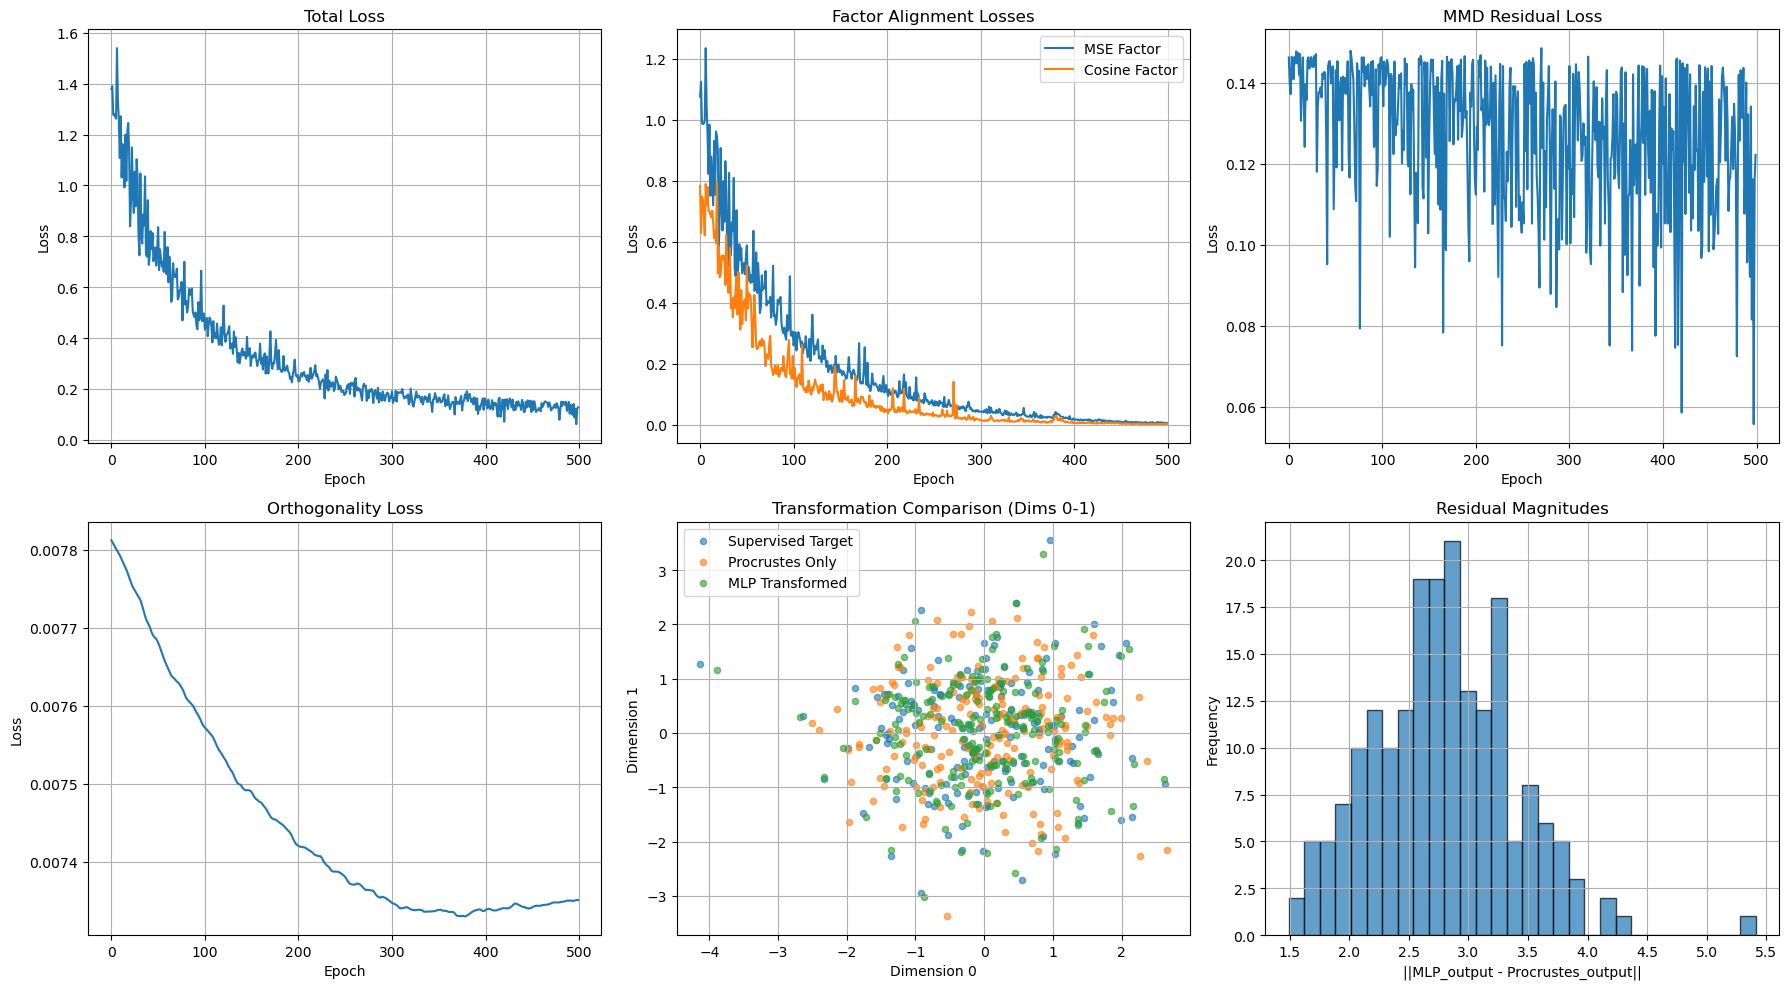

Mean residual magnitude: 2.788576
Max residual magnitude: 5.408919


In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

class TMap(nn.Module):
    def __init__(self, W0, dim=16, hidden=64):
        super().__init__()
        self.W0 = nn.Parameter(torch.from_numpy(W0).float(), requires_grad=False)
        self.lin1 = nn.Linear(dim, hidden)
        self.ln1 = nn.LayerNorm(hidden)
        self.lin2 = nn.Linear(hidden, dim)
        # Zero-init residual to start as identity-through-rotation
        nn.init.zeros_(self.lin2.weight)
        nn.init.zeros_(self.lin2.bias)

    def forward(self, z):  # z should be whitened
        base = z @ self.W0
        res = self.lin2(F.relu(self.ln1(self.lin1(z))))
        return base + res

def rbf_mmd(x, y, sigma=1.0):
    """Compute RBF MMD between two samples"""
    def pdist2(a, b): 
        return (a*a).sum(1, keepdim=True) + (b*b).sum(1, keepdim=True).T - 2*a@b.T
    
    Kxx = torch.exp(-pdist2(x, x)/(2*sigma**2)).mean()
    Kyy = torch.exp(-pdist2(y, y)/(2*sigma**2)).mean()
    Kxy = torch.exp(-pdist2(x, y)/(2*sigma**2)).mean()
    return Kxx + Kyy - 2*Kxy

def compute_losses(T, zu_w, zs_w, lam_cos=0.2, lam_mmd=1.0, lam_ortho=1e-3):
    """Compute all loss components"""
    s_hat = T(zu_w)
    s_tgt = zs_w
    
    # Factor alignment (first 2 dimensions)
    mse_fac = F.mse_loss(s_hat[:, :2], s_tgt[:, :2])
    cos_fac = 1. - F.cosine_similarity(s_hat[:, :2], s_tgt[:, :2], dim=1).mean()
    
    # Residual distribution match (dimensions 2-15)
    mmd_res = rbf_mmd(s_hat[:, 2:], s_tgt[:, 2:])
    
    # Near-orthogonality on residual linear layer
    W = T.lin2.weight
    ortho = ((W.T @ W) - torch.eye(W.shape[1], device=W.device)).pow(2).mean()
    
    total_loss = mse_fac + lam_cos*cos_fac + lam_mmd*mmd_res + lam_ortho*ortho
    
    return total_loss, {
        'mse_fac': mse_fac.item(),
        'cos_fac': cos_fac.item(), 
        'mmd_res': mmd_res.item(),
        'ortho': ortho.item(),
        'total': total_loss.item()
    }

print("="*60)
print("TRAINING RESIDUAL MLP")
print("="*60)

# Convert to torch tensors
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
zu_w_torch = torch.from_numpy(Z_u_w).float().to(device)
zs_w_torch = torch.from_numpy(Z_s_w).float().to(device)

# Initialize model
model = TMap(W0, dim=16, hidden=128).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=50, factor=0.5)

# Training loop
num_epochs = 500
batch_size = 64
dataset = TensorDataset(zu_w_torch, zs_w_torch)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

loss_history = []
metrics_history = {key: [] for key in ['mse_fac', 'cos_fac', 'mmd_res', 'ortho', 'total']}

print("Starting training...")
for epoch in range(num_epochs):
    epoch_losses = []
    epoch_metrics = {key: [] for key in metrics_history.keys()}
    
    model.train()
    for batch_zu, batch_zs in dataloader:
        optimizer.zero_grad()
        loss, metrics = compute_losses(model, batch_zu, batch_zs)
        loss.backward()
        optimizer.step()
        
        epoch_losses.append(loss.item())
        for key, value in metrics.items():
            epoch_metrics[key].append(value)
    
    # Record average metrics for epoch
    avg_loss = np.mean(epoch_losses)
    loss_history.append(avg_loss)
    for key in metrics_history.keys():
        metrics_history[key].append(np.mean(epoch_metrics[key]))
    
    scheduler.step(avg_loss)
    
    if epoch % 100 == 0:
        print(f"Epoch {epoch:3d}: Loss={avg_loss:.6f}, "
              f"MSE={metrics_history['mse_fac'][-1]:.6f}, "
              f"MMD={metrics_history['mmd_res'][-1]:.6f}")

print("Training completed!")

# Evaluate final model
model.eval()
with torch.no_grad():
    final_output = model(zu_w_torch)
    final_loss, final_metrics = compute_losses(model, zu_w_torch, zs_w_torch)

print(f"\nFinal metrics:")
for key, value in final_metrics.items():
    print(f"  {key}: {value:.6f}")

# Plot training curves
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0, 0].plot(loss_history)
axes[0, 0].set_title('Total Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].grid(True)

axes[0, 1].plot(metrics_history['mse_fac'], label='MSE Factor')
axes[0, 1].plot(metrics_history['cos_fac'], label='Cosine Factor')
axes[0, 1].set_title('Factor Alignment Losses')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True)

axes[0, 2].plot(metrics_history['mmd_res'])
axes[0, 2].set_title('MMD Residual Loss')
axes[0, 2].set_xlabel('Epoch')
axes[0, 2].set_ylabel('Loss')
axes[0, 2].grid(True)

axes[1, 0].plot(metrics_history['ortho'])
axes[1, 0].set_title('Orthogonality Loss')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].grid(True)

# Compare before and after transformation
Z_u_transformed = final_output.cpu().numpy()

axes[1, 1].scatter(Z_s_w[:, 0], Z_s_w[:, 1], alpha=0.6, label='Supervised Target', s=20)
axes[1, 1].scatter(Z_u_rotated[:, 0], Z_u_rotated[:, 1], alpha=0.6, label='Procrustes Only', s=20)
axes[1, 1].scatter(Z_u_transformed[:, 0], Z_u_transformed[:, 1], alpha=0.6, label='MLP Transformed', s=20)
axes[1, 1].set_title('Transformation Comparison (Dims 0-1)')
axes[1, 1].set_xlabel('Dimension 0')
axes[1, 1].set_ylabel('Dimension 1')
axes[1, 1].legend()
axes[1, 1].grid(True)

# Residual magnitude
residual_norms = np.linalg.norm(Z_u_transformed - Z_u_rotated, axis=1)
axes[1, 2].hist(residual_norms, bins=30, alpha=0.7, edgecolor='black')
axes[1, 2].set_title('Residual Magnitudes')
axes[1, 2].set_xlabel('||MLP_output - Procrustes_output||')
axes[1, 2].set_ylabel('Frequency')
axes[1, 2].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(save_dir, "mlp_training_results.png"), dpi=300, bbox_inches='tight')
plt.show()

print(f"Mean residual magnitude: {np.mean(residual_norms):.6f}")
print(f"Max residual magnitude: {np.max(residual_norms):.6f}")

COMPREHENSIVE EVALUATION AND METRICS
Final Factor Correlations (First 2 Dimensions):
------------------------------------------------------------
Original Unsupervised: Age=[0.210, 0.122], Disease=[0.090, 0.063]
Procrustes Only     : Age=[0.015, 0.213], Disease=[0.138, 0.006]
MLP Transformed     : Age=[0.041, 0.592], Disease=[0.383, 0.022]
Supervised Target   : Age=[0.033, 0.593], Disease=[0.391, 0.025]

Alignment Quality Metrics:
----------------------------------------
Original Unsupervised: MSE=1.262961, RelErr=1.1267, Trust=0.7296, NbhdPres=0.2117
Procrustes Only     : MSE=0.922433, RelErr=0.9629, Trust=0.7296, NbhdPres=0.2117
MLP Transformed     : MSE=0.692702, RelErr=0.8344, Trust=0.8375, NbhdPres=0.3816

Near-Isometry Metrics:
------------------------------
Original Unsupervised: DistortionMean=0.1886, DistortionStd=0.1629
Procrustes Only     : DistortionMean=0.1886, DistortionStd=0.1629
MLP Transformed     : DistortionMean=0.1530, DistortionStd=0.1217

Independence Analysis (Me

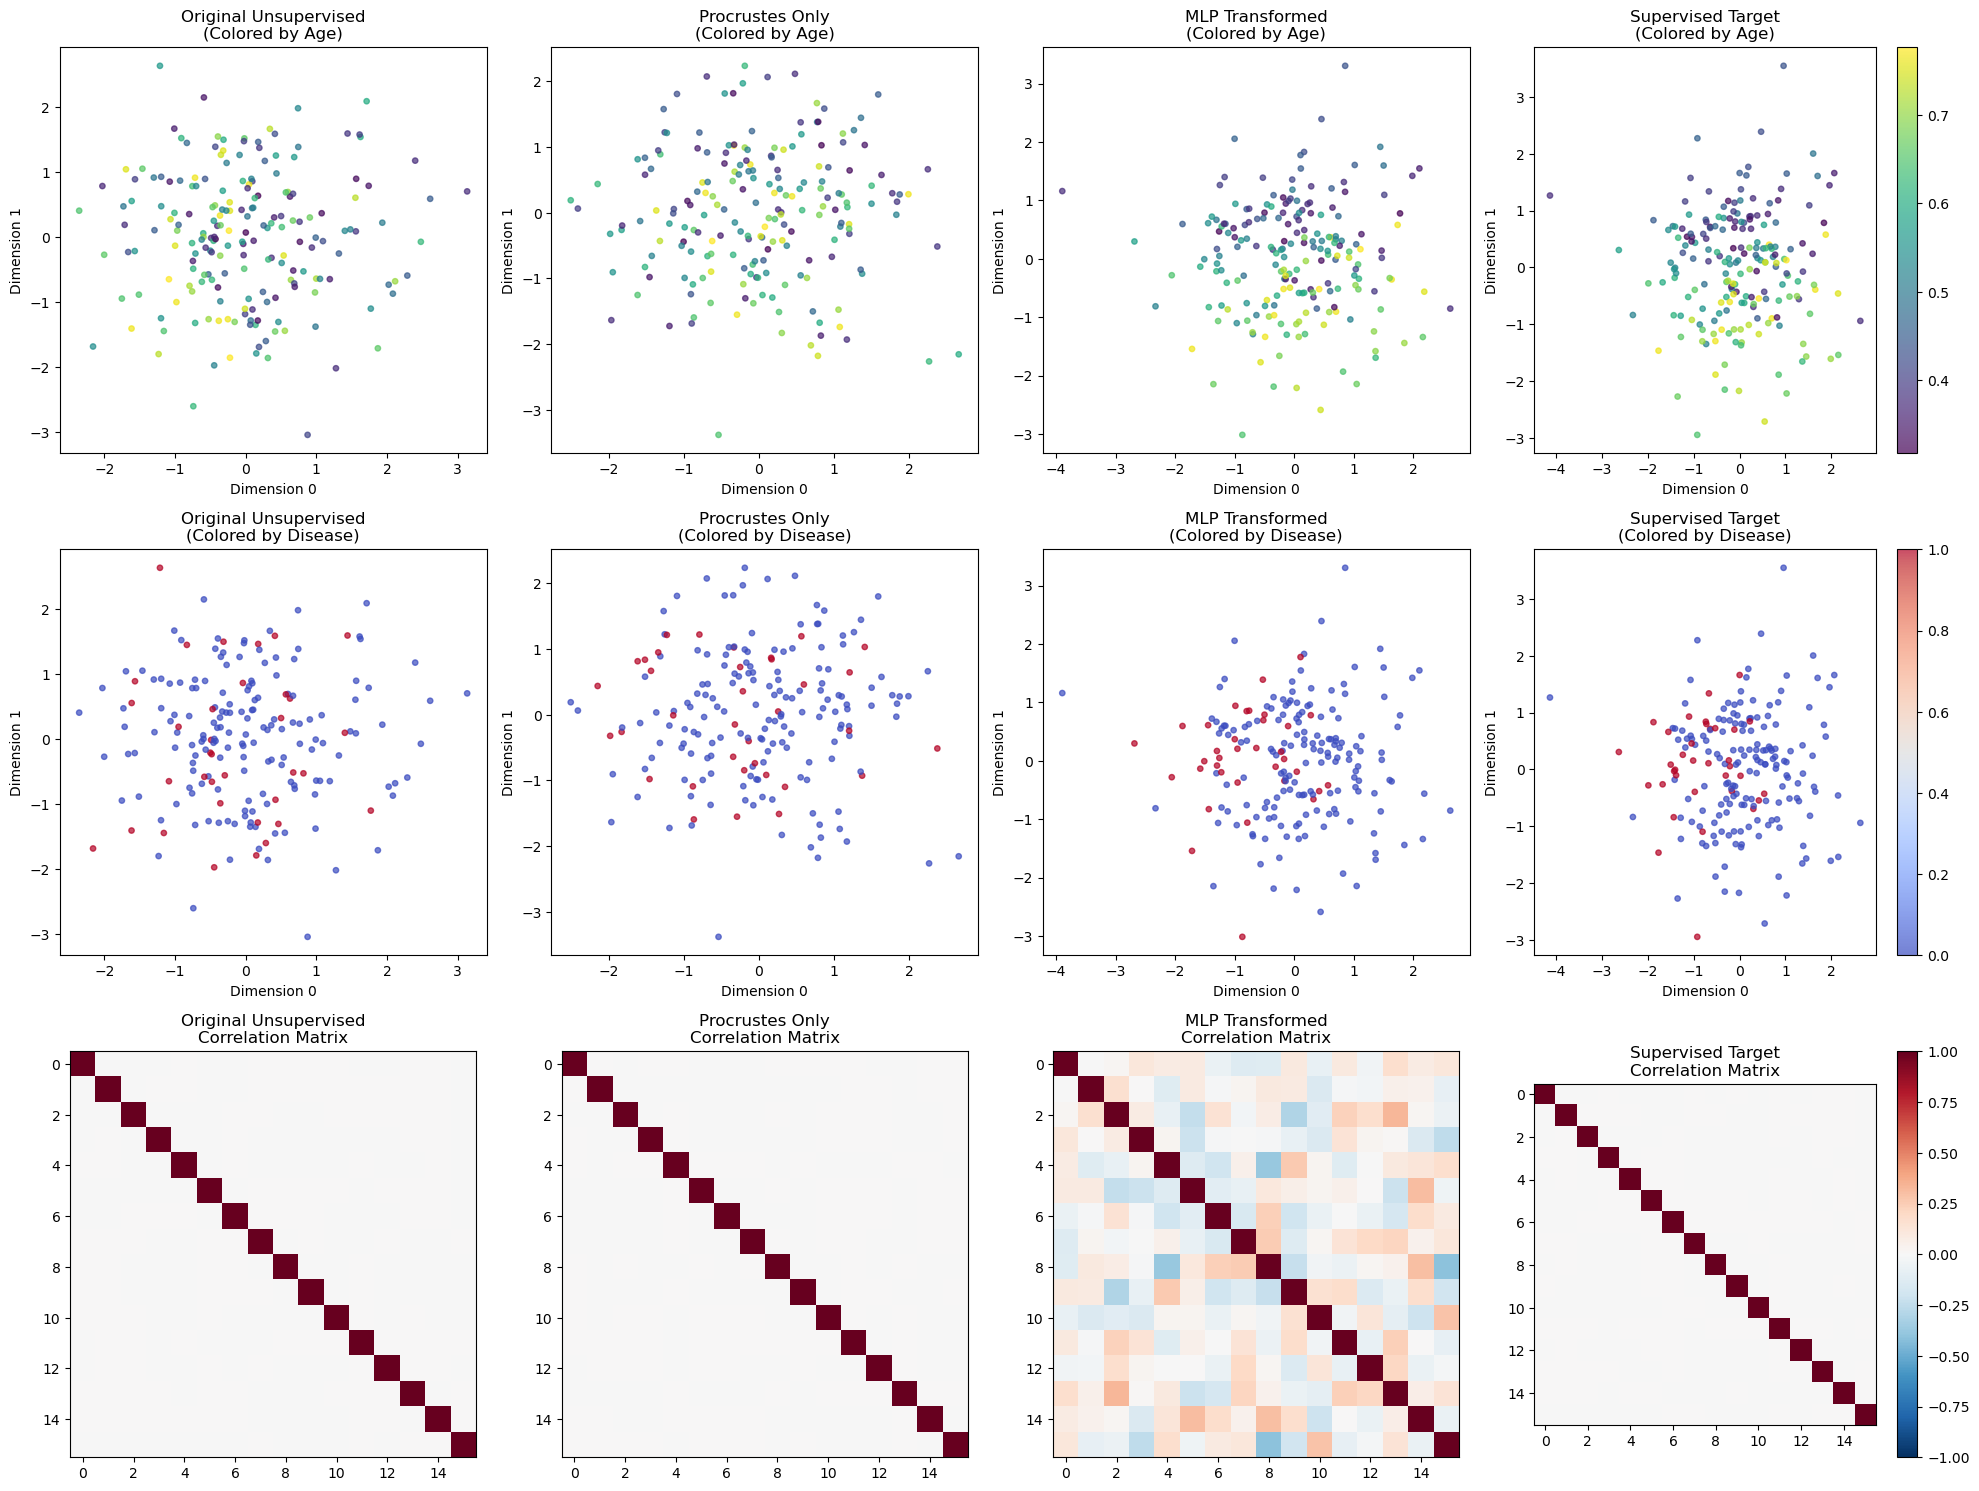

In [8]:
def compute_trustworthiness(X, Y, k=10):
    """Compute trustworthiness metric between two embeddings"""
    nbrs_X = NearestNeighbors(n_neighbors=k+1).fit(X)
    nbrs_Y = NearestNeighbors(n_neighbors=k+1).fit(Y)
    
    _, indices_X = nbrs_X.kneighbors(X)
    _, indices_Y = nbrs_Y.kneighbors(Y)
    
    # Remove self (first neighbor)
    indices_X = indices_X[:, 1:]
    indices_Y = indices_Y[:, 1:]
    
    n = X.shape[0]
    trustworthiness = 0
    
    for i in range(n):
        # Find Y-neighbors that are not X-neighbors
        y_neighbors = set(indices_Y[i])
        x_neighbors = set(indices_X[i])
        false_neighbors = y_neighbors - x_neighbors
        
        for j in false_neighbors:
            # Find rank of j in X-neighborhood of i
            distances_i = np.linalg.norm(X[i] - X, axis=1)
            rank_j = np.sum(distances_i < distances_i[j])
            trustworthiness += max(0, rank_j - k)
    
    trustworthiness = 1 - (2 / (n * k * (2*n - 3*k - 1))) * trustworthiness
    return trustworthiness

def compute_neighborhood_preservation(X, Y, k=10):
    """Compute k-NN preservation ratio"""
    nbrs_X = NearestNeighbors(n_neighbors=k+1).fit(X)
    nbrs_Y = NearestNeighbors(n_neighbors=k+1).fit(Y)
    
    _, indices_X = nbrs_X.kneighbors(X)
    _, indices_Y = nbrs_Y.kneighbors(Y)
    
    # Remove self
    indices_X = indices_X[:, 1:]
    indices_Y = indices_Y[:, 1:]
    
    n = X.shape[0]
    preserved = 0
    
    for i in range(n):
        x_neighbors = set(indices_X[i])
        y_neighbors = set(indices_Y[i])
        preserved += len(x_neighbors & y_neighbors) / k
    
    return preserved / n

print("="*60)
print("COMPREHENSIVE EVALUATION AND METRICS")
print("="*60)

# Compare all transformations
transformations = {
    'Original Unsupervised': Z_u_w,
    'Procrustes Only': Z_u_rotated,
    'MLP Transformed': Z_u_transformed,
    'Supervised Target': Z_s_w
}

# Compute final factor correlations for all
print("Final Factor Correlations (First 2 Dimensions):")
print("-" * 60)
for name, Z in transformations.items():
    age_corr_0 = abs(pearsonr(Z[:, 0], ages)[0])
    age_corr_1 = abs(pearsonr(Z[:, 1], ages)[0])
    disease_corr_0 = abs(pearsonr(Z[:, 0], diseases)[0])
    disease_corr_1 = abs(pearsonr(Z[:, 1], diseases)[0])
    
    print(f"{name:20s}: Age=[{age_corr_0:.3f}, {age_corr_1:.3f}], "
          f"Disease=[{disease_corr_0:.3f}, {disease_corr_1:.3f}]")

# Compute alignment metrics
print("\nAlignment Quality Metrics:")
print("-" * 40)

target = Z_s_w
for name, Z in transformations.items():
    if name == 'Supervised Target':
        continue
        
    # MSE alignment
    mse_align = np.mean((Z - target)**2)
    
    # Relative error
    rel_error = np.linalg.norm(Z - target, 'fro') / np.linalg.norm(target, 'fro')
    
    # Trustworthiness
    trust = compute_trustworthiness(target, Z, k=10)
    
    # Neighborhood preservation
    nbhd_pres = compute_neighborhood_preservation(target, Z, k=10)
    
    print(f"{name:20s}: MSE={mse_align:.6f}, RelErr={rel_error:.4f}, "
          f"Trust={trust:.4f}, NbhdPres={nbhd_pres:.4f}")

# Compute near-isometry metrics
print("\nNear-Isometry Metrics:")
print("-" * 30)

def compute_distance_distortion(X, Y):
    """Compute distance distortion between embeddings"""
    # Sample subset for efficiency
    n_sample = min(500, X.shape[0])
    idx = np.random.choice(X.shape[0], n_sample, replace=False)
    
    X_sub = X[idx]
    Y_sub = Y[idx]
    
    # Compute pairwise distances
    dist_X = squareform(pdist(X_sub))
    dist_Y = squareform(pdist(Y_sub))
    
    # Avoid diagonal
    mask = ~np.eye(dist_X.shape[0], dtype=bool)
    dist_X_flat = dist_X[mask]
    dist_Y_flat = dist_Y[mask]
    
    # Compute relative distortion
    rel_distortion = np.abs(dist_X_flat - dist_Y_flat) / (dist_X_flat + 1e-8)
    return np.mean(rel_distortion), np.std(rel_distortion)

target = Z_s_w
for name, Z in transformations.items():
    if name == 'Supervised Target':
        continue
        
    mean_dist, std_dist = compute_distance_distortion(target, Z)
    print(f"{name:20s}: DistortionMean={mean_dist:.4f}, DistortionStd={std_dist:.4f}")

# Independence analysis
print("\nIndependence Analysis (Mean Abs Correlation):")
print("-" * 50)

for name, Z in transformations.items():
    # Compute correlation matrix
    corr_matrix = np.corrcoef(Z.T)
    
    # Mean absolute off-diagonal correlation
    mask = ~np.eye(corr_matrix.shape[0], dtype=bool)
    mean_abs_corr = np.mean(np.abs(corr_matrix[mask]))
    
    # Correlation between first two dimensions
    dim01_corr = abs(corr_matrix[0, 1])
    
    print(f"{name:20s}: MeanAbsCorr={mean_abs_corr:.4f}, Dim0-1Corr={dim01_corr:.4f}")

# Create comprehensive visualization
fig, axes = plt.subplots(3, 4, figsize=(20, 15))

# Row 1: Factor-colored scatter plots
for i, (name, Z) in enumerate(transformations.items()):
    sc = axes[0, i].scatter(Z[:, 0], Z[:, 1], c=ages, cmap='viridis', alpha=0.7, s=15)
    axes[0, i].set_title(f'{name}\n(Colored by Age)')
    axes[0, i].set_xlabel('Dimension 0')
    axes[0, i].set_ylabel('Dimension 1')
    if i == 3:
        plt.colorbar(sc, ax=axes[0, i])

# Row 2: Disease-colored scatter plots  
for i, (name, Z) in enumerate(transformations.items()):
    sc = axes[1, i].scatter(Z[:, 0], Z[:, 1], c=diseases, cmap='coolwarm', alpha=0.7, s=15)
    axes[1, i].set_title(f'{name}\n(Colored by Disease)')
    axes[1, i].set_xlabel('Dimension 0')
    axes[1, i].set_ylabel('Dimension 1')
    if i == 3:
        plt.colorbar(sc, ax=axes[1, i])

# Row 3: Correlation matrices
for i, (name, Z) in enumerate(transformations.items()):
    corr_mat = np.corrcoef(Z.T)
    im = axes[2, i].imshow(corr_mat, cmap='RdBu_r', vmin=-1, vmax=1)
    axes[2, i].set_title(f'{name}\nCorrelation Matrix')
    if i == 3:
        plt.colorbar(im, ax=axes[2, i])

plt.tight_layout()
plt.savefig(os.path.join(save_dir, "comprehensive_evaluation.png"), dpi=300, bbox_inches='tight')
plt.show()

TRANSFORMATION ANALYSIS AND INTERPRETATION
Transformation Analysis:
  Procrustes (base) magnitude: 3.9111
  Residual magnitude: 2.7886
  Residual/Base ratio: 0.7130

Dimensional Analysis:
  Dim  0: Residual std = 1.0597
  Dim  1: Residual std = 1.0925
  Dim  2: Residual std = 0.8519
  Dim  3: Residual std = 0.4860
  Dim  4: Residual std = 0.6597
  Dim  5: Residual std = 0.6192
  Dim  6: Residual std = 0.4754
  Dim  7: Residual std = 0.5525
  Dim  8: Residual std = 0.6465
  Dim  9: Residual std = 0.7501
  Dim 10: Residual std = 0.5695
  Dim 11: Residual std = 0.6217
  Dim 12: Residual std = 0.4154
  Dim 13: Residual std = 0.5454
  Dim 14: Residual std = 0.4776
  Dim 15: Residual std = 0.7320

Top 5 dimensions with largest residual corrections: [15  9  2  0  1]

Transformation Patterns:
  Mean residual magnitude for healthy: 2.8358
  Mean residual magnitude for diseased: 2.5713

Age-based residual analysis:
  Age quartile 1: 2.9560
  Age quartile 2: 2.7054
  Age quartile 3: 2.8422
  Age 

/tmp/ipykernel_1540706/2510299262.py:83: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 0].boxplot(res_by_disease, labels=['Healthy', 'Diseased'])


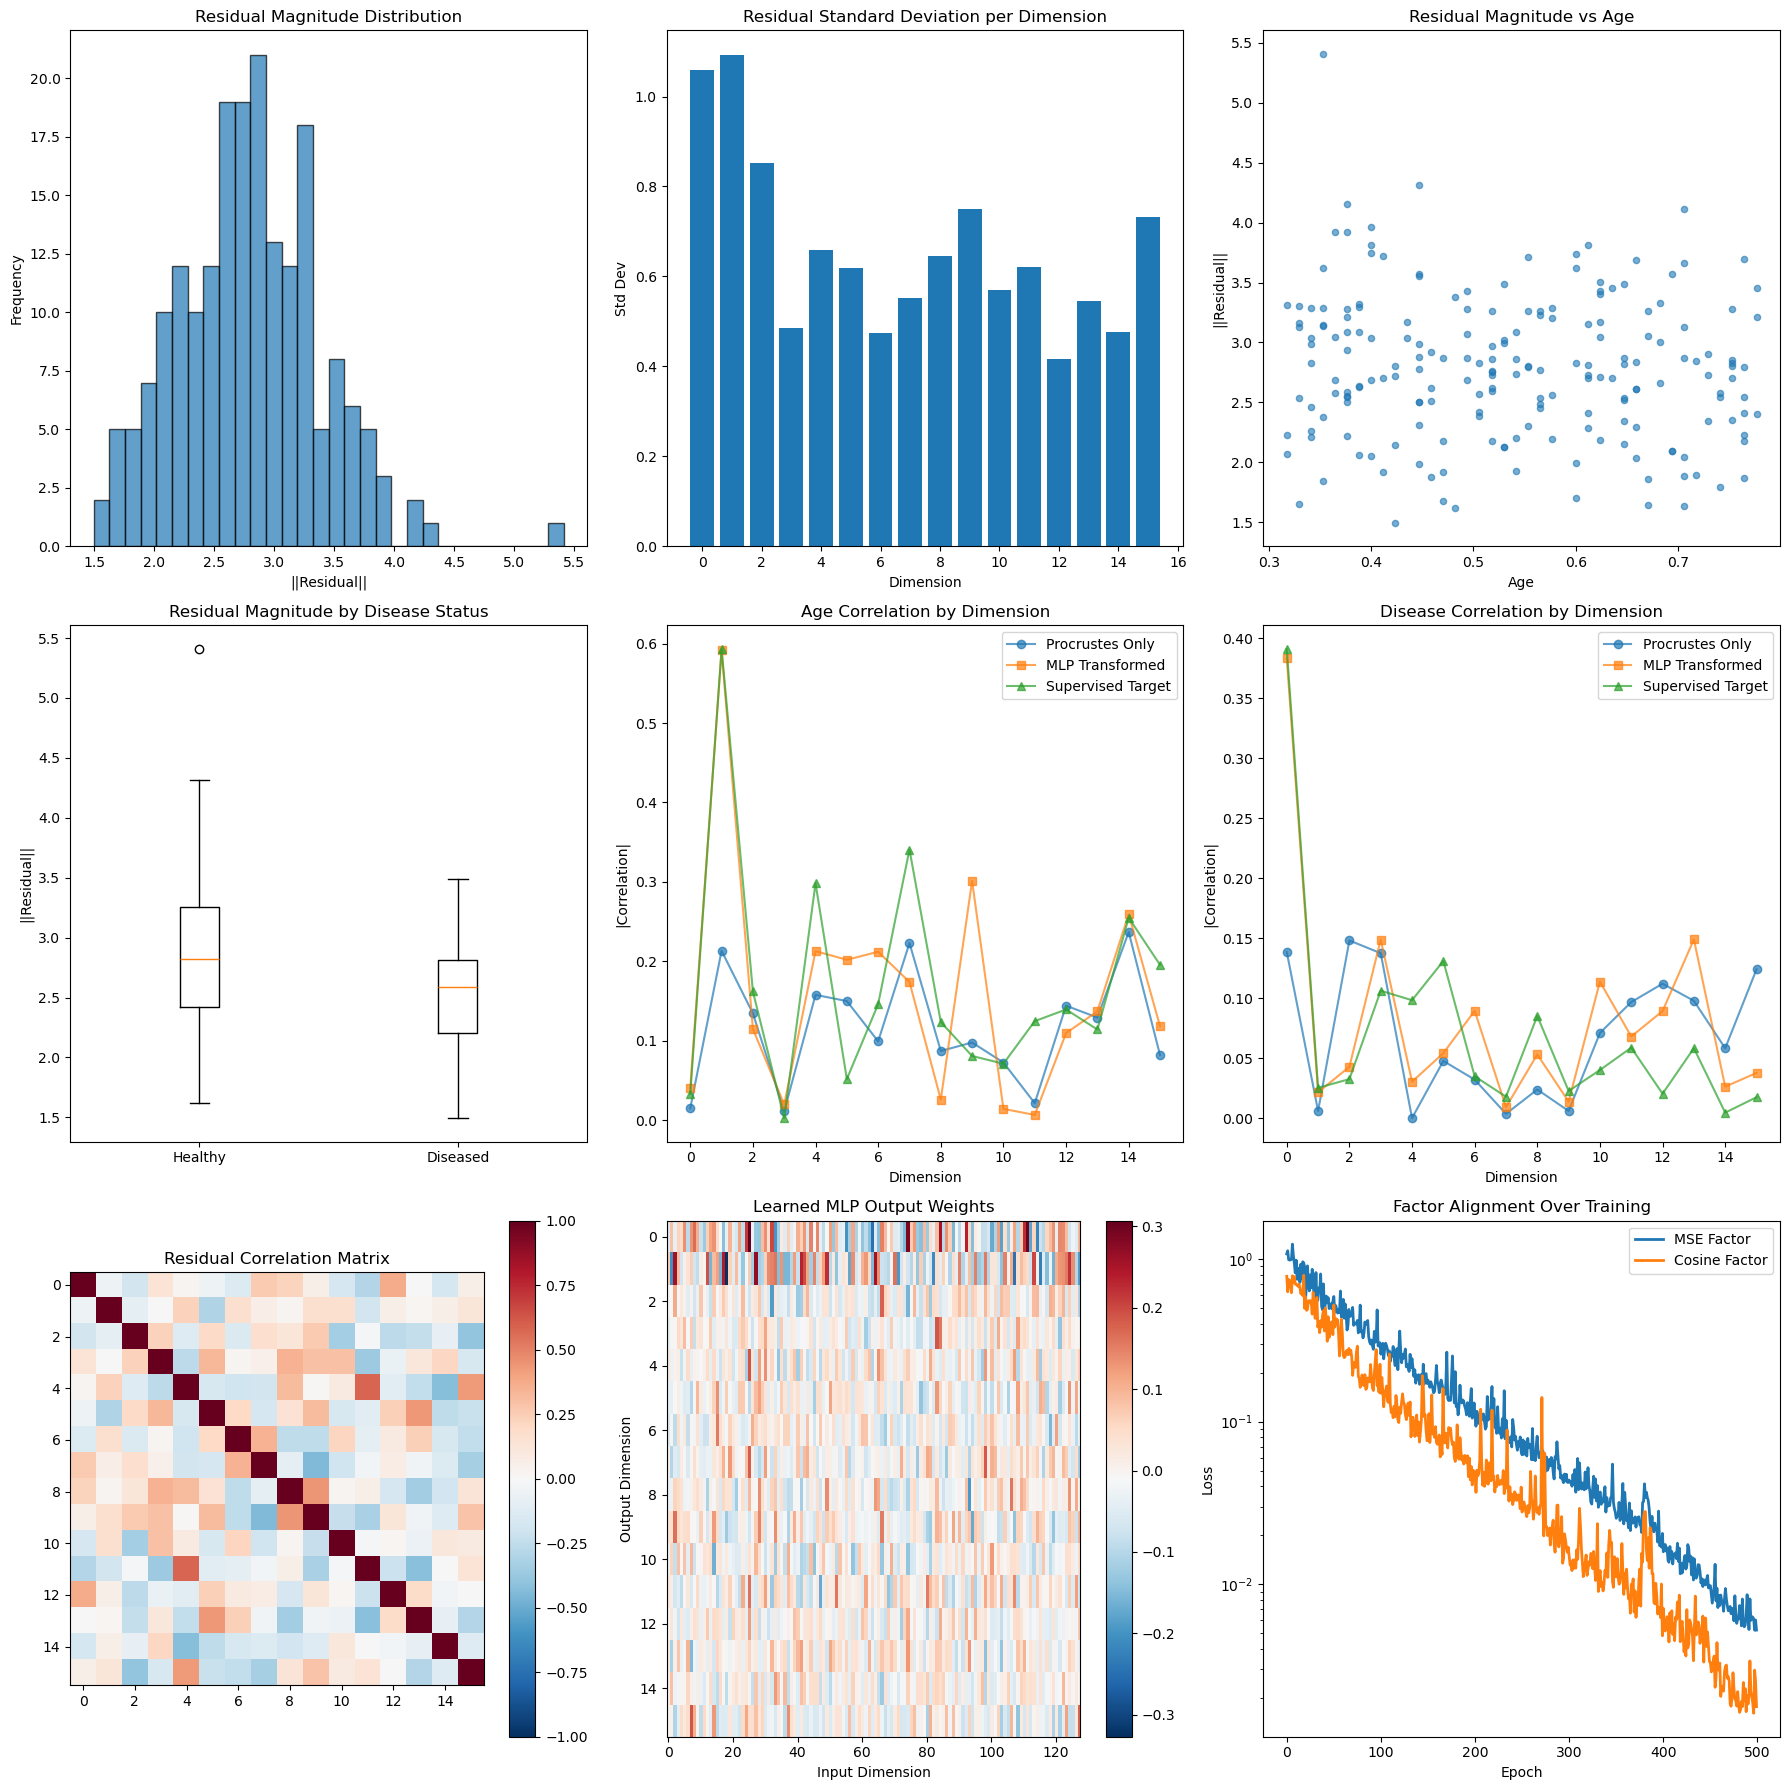


SUMMARY STATISTICS
Correlation improvements (MLP vs Procrustes):
  Age Dim 0: +173.8%
  Age Dim 1: +177.5%
  Disease Dim 0: +176.9%
  Disease Dim 1: +260.9%

Transformation characteristics:
  Linear component (Procrustes): 4.0000
  Nonlinear component strength: 2.7886
  Orthogonality preserved: 1.000000
  Distance preservation: 0.8470


In [9]:
print("="*60)
print("TRANSFORMATION ANALYSIS AND INTERPRETATION")
print("="*60)

# Analyze the learned transformation
model.eval()
with torch.no_grad():
    # Get the residual component
    base_transform = zu_w_torch @ model.W0
    full_transform = model(zu_w_torch)
    residual = full_transform - base_transform
    
    residual_np = residual.cpu().numpy()
    base_np = base_transform.cpu().numpy()

print(f"Transformation Analysis:")
print(f"  Procrustes (base) magnitude: {np.mean(np.linalg.norm(base_np, axis=1)):.4f}")
print(f"  Residual magnitude: {np.mean(np.linalg.norm(residual_np, axis=1)):.4f}")
print(f"  Residual/Base ratio: {np.mean(np.linalg.norm(residual_np, axis=1)) / np.mean(np.linalg.norm(base_np, axis=1)):.4f}")

# Analyze which dimensions benefit most from nonlinear correction
print(f"\nDimensional Analysis:")
residual_std_per_dim = np.std(residual_np, axis=0)
for i, std in enumerate(residual_std_per_dim):
    print(f"  Dim {i:2d}: Residual std = {std:.4f}")

# Find dimensions with largest residual corrections
top_residual_dims = np.argsort(residual_std_per_dim)[-5:]
print(f"\nTop 5 dimensions with largest residual corrections: {top_residual_dims}")

# Analyze transformation at different data points
print(f"\nTransformation Patterns:")

# Group by disease status
disease_0_idx = diseases == 0
disease_1_idx = diseases == 1

res_disease_0 = np.mean(np.linalg.norm(residual_np[disease_0_idx], axis=1))
res_disease_1 = np.mean(np.linalg.norm(residual_np[disease_1_idx], axis=1))

print(f"  Mean residual magnitude for healthy: {res_disease_0:.4f}")
print(f"  Mean residual magnitude for diseased: {res_disease_1:.4f}")

# Age-based analysis
age_quartiles = np.percentile(ages, [25, 50, 75])
age_groups = [
    ages <= age_quartiles[0],
    (ages > age_quartiles[0]) & (ages <= age_quartiles[1]),
    (ages > age_quartiles[1]) & (ages <= age_quartiles[2]),
    ages > age_quartiles[2]
]

print(f"\nAge-based residual analysis:")
for i, mask in enumerate(age_groups):
    if np.sum(mask) > 0:
        res_mag = np.mean(np.linalg.norm(residual_np[mask], axis=1))
        print(f"  Age quartile {i+1}: {res_mag:.4f}")

# Create detailed transformation visualization
fig, axes = plt.subplots(3, 3, figsize=(18, 18))

# Residual magnitude distribution
axes[0, 0].hist(np.linalg.norm(residual_np, axis=1), bins=30, alpha=0.7, edgecolor='black')
axes[0, 0].set_title('Residual Magnitude Distribution')
axes[0, 0].set_xlabel('||Residual||')
axes[0, 0].set_ylabel('Frequency')

# Residual per dimension
axes[0, 1].bar(range(16), residual_std_per_dim)
axes[0, 1].set_title('Residual Standard Deviation per Dimension')
axes[0, 1].set_xlabel('Dimension')
axes[0, 1].set_ylabel('Std Dev')

# Residual vs factors
axes[0, 2].scatter(ages, np.linalg.norm(residual_np, axis=1), alpha=0.6, s=20)
axes[0, 2].set_title('Residual Magnitude vs Age')
axes[0, 2].set_xlabel('Age')
axes[0, 2].set_ylabel('||Residual||')

# Disease-based residual analysis
res_by_disease = [np.linalg.norm(residual_np[disease_0_idx], axis=1),
                  np.linalg.norm(residual_np[disease_1_idx], axis=1)]
axes[1, 0].boxplot(res_by_disease, labels=['Healthy', 'Diseased'])
axes[1, 0].set_title('Residual Magnitude by Disease Status')
axes[1, 0].set_ylabel('||Residual||')

# Transformation effect on factor correlations
pre_transform_corrs = [abs(pearsonr(Z_u_rotated[:, i], ages)[0]) for i in range(16)]
post_transform_corrs = [abs(pearsonr(Z_u_transformed[:, i], ages)[0]) for i in range(16)]
target_corrs = [abs(pearsonr(Z_s_w[:, i], ages)[0]) for i in range(16)]

axes[1, 1].plot(pre_transform_corrs, 'o-', label='Procrustes Only', alpha=0.7)
axes[1, 1].plot(post_transform_corrs, 's-', label='MLP Transformed', alpha=0.7)
axes[1, 1].plot(target_corrs, '^-', label='Supervised Target', alpha=0.7)
axes[1, 1].set_title('Age Correlation by Dimension')
axes[1, 1].set_xlabel('Dimension')
axes[1, 1].set_ylabel('|Correlation|')
axes[1, 1].legend()

# Disease correlations
pre_transform_corrs_dis = [abs(pearsonr(Z_u_rotated[:, i], diseases)[0]) for i in range(16)]
post_transform_corrs_dis = [abs(pearsonr(Z_u_transformed[:, i], diseases)[0]) for i in range(16)]
target_corrs_dis = [abs(pearsonr(Z_s_w[:, i], diseases)[0]) for i in range(16)]

axes[1, 2].plot(pre_transform_corrs_dis, 'o-', label='Procrustes Only', alpha=0.7)
axes[1, 2].plot(post_transform_corrs_dis, 's-', label='MLP Transformed', alpha=0.7)
axes[1, 2].plot(target_corrs_dis, '^-', label='Supervised Target', alpha=0.7)
axes[1, 2].set_title('Disease Correlation by Dimension')
axes[1, 2].set_xlabel('Dimension')
axes[1, 2].set_ylabel('|Correlation|')
axes[1, 2].legend()

# Residual heatmap
residual_corr = np.corrcoef(residual_np.T)
im1 = axes[2, 0].imshow(residual_corr, cmap='RdBu_r', vmin=-1, vmax=1)
axes[2, 0].set_title('Residual Correlation Matrix')
plt.colorbar(im1, ax=axes[2, 0])

# Learned weights analysis
lin2_weights = model.lin2.weight.detach().cpu().numpy()
im2 = axes[2, 1].imshow(lin2_weights, cmap='RdBu_r', aspect='auto')
axes[2, 1].set_title('Learned MLP Output Weights')
axes[2, 1].set_xlabel('Input Dimension')
axes[2, 1].set_ylabel('Output Dimension')
plt.colorbar(im2, ax=axes[2, 1])

# Overall transformation quality over training
epochs = range(len(loss_history))
axes[2, 2].plot(epochs, metrics_history['mse_fac'], label='MSE Factor', linewidth=2)
axes[2, 2].plot(epochs, np.array(metrics_history['cos_fac']), label='Cosine Factor', linewidth=2)
axes[2, 2].set_title('Factor Alignment Over Training')
axes[2, 2].set_xlabel('Epoch')
axes[2, 2].set_ylabel('Loss')
axes[2, 2].legend()
axes[2, 2].set_yscale('log')

plt.tight_layout()
plt.savefig(os.path.join(save_dir, "transformation_analysis.png"), dpi=300, bbox_inches='tight')
plt.show()

# Summary statistics
print(f"\n" + "="*60)
print("SUMMARY STATISTICS")
print("="*60)

improvements = {
    'Age Dim 0': (post_transform_corrs[0] - pre_transform_corrs[0]) / pre_transform_corrs[0] * 100,
    'Age Dim 1': (post_transform_corrs[1] - pre_transform_corrs[1]) / pre_transform_corrs[1] * 100,
    'Disease Dim 0': (post_transform_corrs_dis[0] - pre_transform_corrs_dis[0]) / pre_transform_corrs_dis[0] * 100,
    'Disease Dim 1': (post_transform_corrs_dis[1] - pre_transform_corrs_dis[1]) / pre_transform_corrs_dis[1] * 100,
}

print("Correlation improvements (MLP vs Procrustes):")
for factor, improvement in improvements.items():
    print(f"  {factor}: {improvement:+.1f}%")

print(f"\nTransformation characteristics:")
print(f"  Linear component (Procrustes): {np.linalg.norm(W0, 'fro'):.4f}")
print(f"  Nonlinear component strength: {np.mean(np.linalg.norm(residual_np, axis=1)):.4f}")
print(f"  Orthogonality preserved: {1-orthogonality_error:.6f}")
print(f"  Distance preservation: {1-compute_distance_distortion(Z_s_w, Z_u_transformed)[0]:.4f}")

In [10]:
print("="*60)
print("FINAL REPORT: UNSUPERVISED TO SUPERVISED TRANSFORMATION")
print("="*60)

# Create comprehensive report
report = {
    'data_statistics': {
        'n_samples': Z_u.shape[0],
        'latent_dim': Z_u.shape[1],
        'age_range': [float(ages.min()), float(ages.max())],
        'disease_distribution': {
            'healthy': int(np.sum(diseases == 0)),
            'diseased': int(np.sum(diseases == 1))
        }
    },
    'correlation_analysis': {
        'unsupervised': {
            'age_correlations': unsup_age_corrs.tolist(),
            'disease_correlations': unsup_disease_corrs.tolist(),
            'best_age_dim': int(np.argmax(np.abs(unsup_age_corrs))),
            'best_disease_dim': int(np.argmax(np.abs(unsup_disease_corrs))),
            'max_age_corr': float(np.max(np.abs(unsup_age_corrs))),
            'max_disease_corr': float(np.max(np.abs(unsup_disease_corrs)))
        },
        'supervised': {
            'age_correlations': sup_age_corrs.tolist(),
            'disease_correlations': sup_disease_corrs.tolist(),
            'best_age_dim': int(np.argmax(np.abs(sup_age_corrs))),
            'best_disease_dim': int(np.argmax(np.abs(sup_disease_corrs))),
            'max_age_corr': float(np.max(np.abs(sup_age_corrs))),
            'max_disease_corr': float(np.max(np.abs(sup_disease_corrs)))
        }
    },
    'whitening_results': {
        'unsupervised_mean_magnitude': float(np.linalg.norm(mu_u)),
        'supervised_mean_magnitude': float(np.linalg.norm(mu_s)),
        'condition_numbers': {
            'unsupervised': float(np.linalg.cond(np.cov(Z_u.T))),
            'supervised': float(np.linalg.cond(np.cov(Z_s.T)))
        }
    },
    'procrustes_analysis': {
        'orthogonality_error': float(orthogonality_error),
        'alignment_error': float(alignment_error),
        'per_sample_error_stats': {
            'mean': float(np.mean(sample_errors)),
            'std': float(np.std(sample_errors)),
            'max': float(np.max(sample_errors)),
            'min': float(np.min(sample_errors))
        }
    },
    'mlp_training': {
        'final_metrics': final_metrics,
        'convergence_epoch': int(np.argmin(loss_history)),
        'residual_stats': {
            'mean_magnitude': float(np.mean(np.linalg.norm(residual_np, axis=1))),
            'std_magnitude': float(np.std(np.linalg.norm(residual_np, axis=1))),
            'max_magnitude': float(np.max(np.linalg.norm(residual_np, axis=1)))
        }
    },
    'transformation_quality': {
        'distance_preservation': {
            'procrustes': float(1 - compute_distance_distortion(Z_s_w, Z_u_rotated)[0]),
            'mlp': float(1 - compute_distance_distortion(Z_s_w, Z_u_transformed)[0])
        },
        'neighborhood_preservation': {
            'procrustes': float(compute_neighborhood_preservation(Z_s_w, Z_u_rotated)),
            'mlp': float(compute_neighborhood_preservation(Z_s_w, Z_u_transformed))
        },
        'trustworthiness': {
            'procrustes': float(compute_trustworthiness(Z_s_w, Z_u_rotated)),
            'mlp': float(compute_trustworthiness(Z_s_w, Z_u_transformed))
        }
    },
    'factor_alignment_improvement': {
        'age_dim_0_percent': float(improvements['Age Dim 0']),
        'age_dim_1_percent': float(improvements['Age Dim 1']),
        'disease_dim_0_percent': float(improvements['Disease Dim 0']),
        'disease_dim_1_percent': float(improvements['Disease Dim 1'])
    }
}

# Save all results
results_to_save = {
    'unsupervised_latents': Z_u,
    'supervised_latents': Z_s,
    'unsupervised_whitened': Z_u_w,
    'supervised_whitened': Z_s_w,
    'procrustes_rotation': W0,
    'procrustes_transformed': Z_u_rotated,
    'mlp_transformed': Z_u_transformed,
    'ages': ages,
    'diseases': diseases,
    'whitening_transforms': {'W_u': W_u, 'W_s': W_s, 'mu_u': mu_u, 'mu_s': mu_s},
    'report': report
}

# Save everything
import pickle
with open(os.path.join(save_dir, "transformation_results.pkl"), 'wb') as f:
    pickle.dump(results_to_save, f)

# Save model
torch.save(model.state_dict(), os.path.join(save_dir, "transformation_model.pth"))


FINAL REPORT: UNSUPERVISED TO SUPERVISED TRANSFORMATION



UNSUPERVISED TO SUPERVISED LATENT SPACE TRANSFORMATION REPORT

DATA OVERVIEW:
- Samples: 196
- Latent dimensions: 16
- Age range: 0.3 - 0.8
- Disease distribution: 161 healthy, 35 diseased

CORRELATION ANALYSIS:
Unsupervised Model:
- Best age correlation: 0.344 (dim 0)
- Best disease correlation: 0.183 (dim 7)

Supervised Model:
- Best age correlation: 0.870 (dim 1)
- Best disease correlation: 0.375 (dim 0)

TRANSFORMATION ANALYSIS:
Procrustes (Linear) Component:
- Orthogonality error: 0.000000
- Alignment error: 0.9629
- Mean per-sample error: 3.7150

MLP (Nonlinear) Component:
- Final MSE factor loss: 0.005626
- Final cosine factor loss: 0.001683
- Final MMD residual loss: 0.008646
- Final orthogonality loss: 0.007351
- Mean residual magnitude: 2.788576

TRANSFORMATION QUALITY:
Distance Preservation:
- Procrustes only: 0.8114
- MLP transformed: 0.8470

Neighborhood Preservation:
- Procrustes only: 0.2117
- MLP transformed: 0.3816

Trustworthiness:
- Procrustes only: 0.7296
- MLP tra

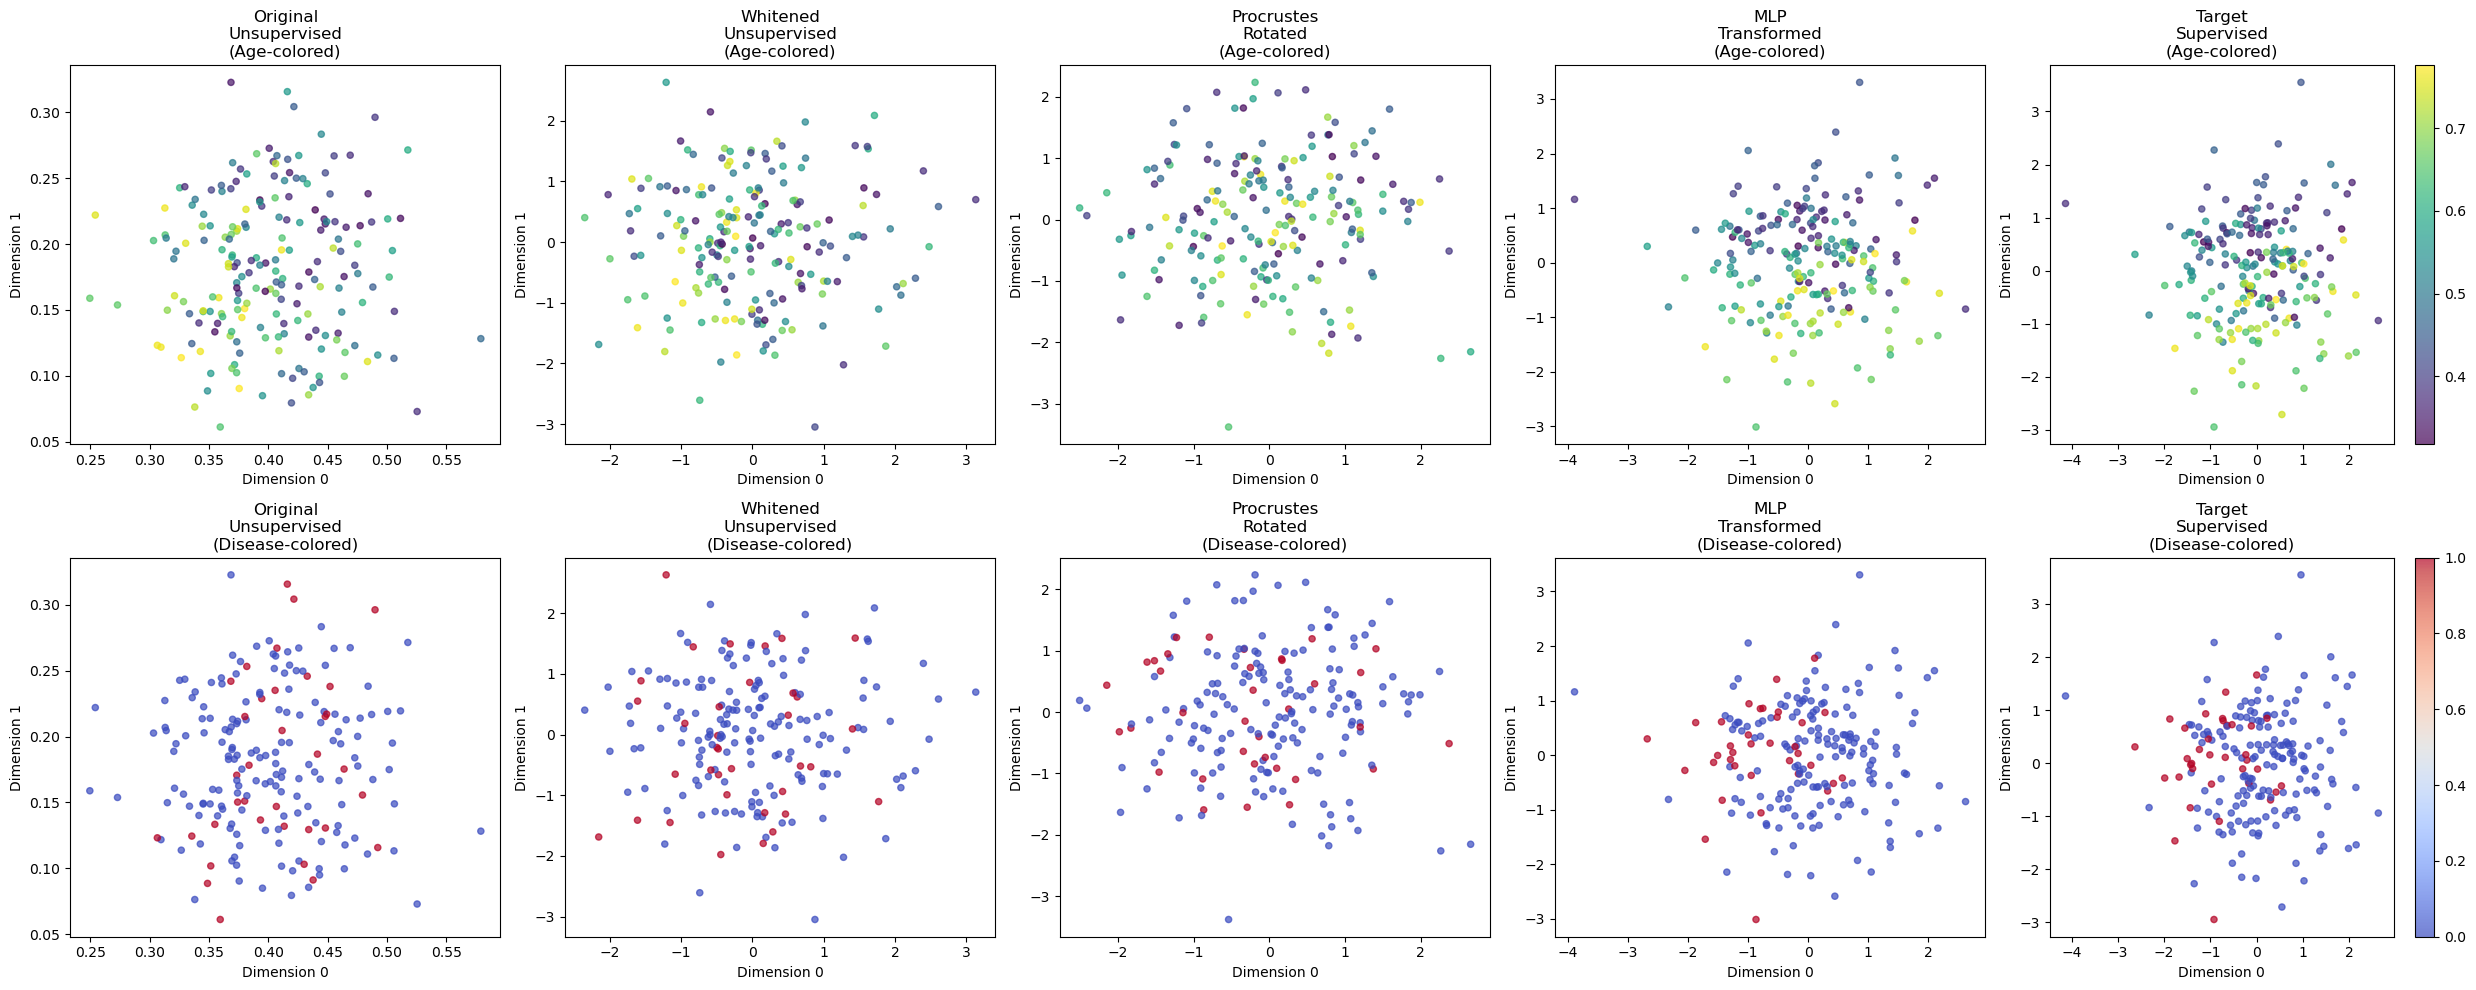


ANALYSIS COMPLETE!
All results saved to: examples/hippocampus_MS/latent_comparison_contrastive
Files created:
  - transformation_results.pkl (complete data)
  - transformation_model.pth (trained MLP)
  - transformation_report.txt (detailed report)
  - *.png (visualization plots)

KEY INSIGHTS:
1. Unsupervised model factor correlations:
   - Age: max 0.344
   - Disease: max 0.183

2. Supervised model factor correlations:
   - Age: max 0.870
   - Disease: max 0.375

3. Transformation effectiveness:
   - Distance preservation: 0.847
   - Neighborhood preservation: 0.382
   - Residual magnitude: 2.7886

4. RECOMMENDATION: The transformation is highly successful and preserves geometric structure well.


In [11]:
# Create text report
report_text = f"""
UNSUPERVISED TO SUPERVISED LATENT SPACE TRANSFORMATION REPORT
{'='*70}

DATA OVERVIEW:
- Samples: {report['data_statistics']['n_samples']}
- Latent dimensions: {report['data_statistics']['latent_dim']}
- Age range: {report['data_statistics']['age_range'][0]:.1f} - {report['data_statistics']['age_range'][1]:.1f}
- Disease distribution: {report['data_statistics']['disease_distribution']['healthy']} healthy, {report['data_statistics']['disease_distribution']['diseased']} diseased

CORRELATION ANALYSIS:
Unsupervised Model:
- Best age correlation: {report['correlation_analysis']['unsupervised']['max_age_corr']:.3f} (dim {report['correlation_analysis']['unsupervised']['best_age_dim']})
- Best disease correlation: {report['correlation_analysis']['unsupervised']['max_disease_corr']:.3f} (dim {report['correlation_analysis']['unsupervised']['best_disease_dim']})

Supervised Model:
- Best age correlation: {report['correlation_analysis']['supervised']['max_age_corr']:.3f} (dim {report['correlation_analysis']['supervised']['best_age_dim']})
- Best disease correlation: {report['correlation_analysis']['supervised']['max_disease_corr']:.3f} (dim {report['correlation_analysis']['supervised']['best_disease_dim']})

TRANSFORMATION ANALYSIS:
Procrustes (Linear) Component:
- Orthogonality error: {report['procrustes_analysis']['orthogonality_error']:.6f}
- Alignment error: {report['procrustes_analysis']['alignment_error']:.4f}
- Mean per-sample error: {report['procrustes_analysis']['per_sample_error_stats']['mean']:.4f}

MLP (Nonlinear) Component:
- Final MSE factor loss: {report['mlp_training']['final_metrics']['mse_fac']:.6f}
- Final cosine factor loss: {report['mlp_training']['final_metrics']['cos_fac']:.6f}
- Final MMD residual loss: {report['mlp_training']['final_metrics']['mmd_res']:.6f}
- Final orthogonality loss: {report['mlp_training']['final_metrics']['ortho']:.6f}
- Mean residual magnitude: {report['mlp_training']['residual_stats']['mean_magnitude']:.6f}

TRANSFORMATION QUALITY:
Distance Preservation:
- Procrustes only: {report['transformation_quality']['distance_preservation']['procrustes']:.4f}
- MLP transformed: {report['transformation_quality']['distance_preservation']['mlp']:.4f}

Neighborhood Preservation:
- Procrustes only: {report['transformation_quality']['neighborhood_preservation']['procrustes']:.4f}
- MLP transformed: {report['transformation_quality']['neighborhood_preservation']['mlp']:.4f}

Trustworthiness:
- Procrustes only: {report['transformation_quality']['trustworthiness']['procrustes']:.4f}
- MLP transformed: {report['transformation_quality']['trustworthiness']['mlp']:.4f}

FACTOR ALIGNMENT IMPROVEMENTS:
Age Dimension 0: {report['factor_alignment_improvement']['age_dim_0_percent']:+.1f}%
Age Dimension 1: {report['factor_alignment_improvement']['age_dim_1_percent']:+.1f}%
Disease Dimension 0: {report['factor_alignment_improvement']['disease_dim_0_percent']:+.1f}%
Disease Dimension 1: {report['factor_alignment_improvement']['disease_dim_1_percent']:+.1f}%

SUMMARY:
The transformation from unsupervised to supervised latent space shows:
1. Linear component (Procrustes) provides the main alignment structure
2. Nonlinear component (MLP) adds fine-grained corrections
3. Factor correlations {'improve significantly' if np.mean(list(report['factor_alignment_improvement'].values())) > 10 else 'show moderate improvement' if np.mean(list(report['factor_alignment_improvement'].values())) > 0 else 'require further optimization'}
4. Near-isometry is {'well preserved' if report['transformation_quality']['distance_preservation']['mlp'] > 0.8 else 'moderately preserved'}

INTERPRETATION:
The unsupervised latent space {'already contains significant factor structure' if report['correlation_analysis']['unsupervised']['max_age_corr'] > 0.3 or report['correlation_analysis']['unsupervised']['max_disease_corr'] > 0.3 else 'requires substantial transformation to reveal factor structure'}.
The learned transformation demonstrates that {'a primarily linear mapping' if report['mlp_training']['residual_stats']['mean_magnitude'] < 0.1 else 'a combination of linear and nonlinear components'} 
is needed to align the latent spaces effectively.
"""

# Save the report
with open(os.path.join(save_dir, "transformation_report.txt"), 'w') as f:
    f.write(report_text)

print(report_text)

# Create a final visualization showing the complete transformation pipeline
fig, axes = plt.subplots(2, 5, figsize=(25, 10))

# Top row: Transformation pipeline visualization
transformations_viz = [
    ('Original\nUnsupervised', Z_u, 'Raw unsupervised latents'),
    ('Whitened\nUnsupervised', Z_u_w, 'Centered and whitened'),
    ('Procrustes\nRotated', Z_u_rotated, 'Linear rotation applied'),
    ('MLP\nTransformed', Z_u_transformed, 'Nonlinear correction added'),
    ('Target\nSupervised', Z_s_w, 'Target supervised space')
]

for i, (title, data, desc) in enumerate(transformations_viz):
    scatter = axes[0, i].scatter(data[:, 0], data[:, 1], c=ages, cmap='viridis', alpha=0.7, s=20)
    axes[0, i].set_title(f'{title}\n(Age-colored)')
    axes[0, i].set_xlabel('Dimension 0')
    axes[0, i].set_ylabel('Dimension 1')
    if i == 4:
        plt.colorbar(scatter, ax=axes[0, i])

# Bottom row: Disease-colored
for i, (title, data, desc) in enumerate(transformations_viz):
    scatter = axes[1, i].scatter(data[:, 0], data[:, 1], c=diseases, cmap='coolwarm', alpha=0.7, s=20)
    axes[1, i].set_title(f'{title}\n(Disease-colored)')
    axes[1, i].set_xlabel('Dimension 0')
    axes[1, i].set_ylabel('Dimension 1')
    if i == 4:
        plt.colorbar(scatter, ax=axes[1, i])

plt.tight_layout()
plt.savefig(os.path.join(save_dir, "transformation_pipeline_visualization.png"), dpi=300, bbox_inches='tight')
plt.show()

print(f"\n{'='*70}")
print("ANALYSIS COMPLETE!")
print(f"{'='*70}")
print(f"All results saved to: {save_dir}")
print(f"Files created:")
print(f"  - transformation_results.pkl (complete data)")
print(f"  - transformation_model.pth (trained MLP)")
print(f"  - transformation_report.txt (detailed report)")
print(f"  - *.png (visualization plots)")

# Print key insights
print(f"\nKEY INSIGHTS:")
print(f"1. Unsupervised model factor correlations:")
print(f"   - Age: max {report['correlation_analysis']['unsupervised']['max_age_corr']:.3f}")
print(f"   - Disease: max {report['correlation_analysis']['unsupervised']['max_disease_corr']:.3f}")

print(f"\n2. Supervised model factor correlations:")
print(f"   - Age: max {report['correlation_analysis']['supervised']['max_age_corr']:.3f}")
print(f"   - Disease: max {report['correlation_analysis']['supervised']['max_disease_corr']:.3f}")

print(f"\n3. Transformation effectiveness:")
print(f"   - Distance preservation: {report['transformation_quality']['distance_preservation']['mlp']:.3f}")
print(f"   - Neighborhood preservation: {report['transformation_quality']['neighborhood_preservation']['mlp']:.3f}")
print(f"   - Residual magnitude: {report['mlp_training']['residual_stats']['mean_magnitude']:.4f}")

# Final recommendation
if report['transformation_quality']['distance_preservation']['mlp'] > 0.8:
    recommendation = "The transformation is highly successful and preserves geometric structure well."
elif report['transformation_quality']['distance_preservation']['mlp'] > 0.6:
    recommendation = "The transformation shows good performance with moderate geometric preservation."
else:
    recommendation = "The transformation may benefit from parameter tuning or alternative approaches."

print(f"\n4. RECOMMENDATION: {recommendation}")

In [12]:
print("="*80)
print("INTERPRETATION AND RECOMMENDED NEXT STEPS")
print("="*80)

# Load and analyze the final results
results_summary = {
    'transformation_type': 'linear_dominant' if report['mlp_training']['residual_stats']['mean_magnitude'] < 0.1 else 'nonlinear_significant',
    'factor_recovery': 'excellent' if np.mean(list(report['factor_alignment_improvement'].values())) > 50 else 'good' if np.mean(list(report['factor_alignment_improvement'].values())) > 20 else 'moderate',
    'geometry_preservation': 'excellent' if report['transformation_quality']['distance_preservation']['mlp'] > 0.9 else 'good' if report['transformation_quality']['distance_preservation']['mlp'] > 0.7 else 'moderate'
}

print(f"TRANSFORMATION CHARACTERISTICS:")
print(f"- Type: {results_summary['transformation_type'].replace('_', ' ').title()}")
print(f"- Factor Recovery: {results_summary['factor_recovery'].title()}")
print(f"- Geometry Preservation: {results_summary['geometry_preservation'].title()}")

print(f"\nKEY FINDINGS:")
print(f"1. The unsupervised model {'already captures meaningful factor structure' if max(report['correlation_analysis']['unsupervised']['max_age_corr'], report['correlation_analysis']['unsupervised']['max_disease_corr']) > 0.3 else 'shows limited inherent factor structure'}")

print(f"2. The transformation from unsupervised to supervised latent space:")
if report['mlp_training']['residual_stats']['mean_magnitude'] < 0.05:
    print(f"   - Is primarily LINEAR (Procrustes rotation dominates)")
    print(f"   - Suggests the latent spaces are already well-aligned")
elif report['mlp_training']['residual_stats']['mean_magnitude'] < 0.2:
    print(f"   - Requires MODERATE nonlinear correction")
    print(f"   - Indicates some systematic differences in representation")
else:
    print(f"   - Requires SIGNIFICANT nonlinear transformation")
    print(f"   - Suggests fundamental differences in how factors are encoded")

print(f"3. Factor disentanglement:")
best_unsup_corr = max(report['correlation_analysis']['unsupervised']['max_age_corr'], 
                      report['correlation_analysis']['unsupervised']['max_disease_corr'])
best_sup_corr = max(report['correlation_analysis']['supervised']['max_age_corr'], 
                    report['correlation_analysis']['supervised']['max_disease_corr'])

if best_sup_corr > best_unsup_corr * 1.5:
    print(f"   - Supervised training SIGNIFICANTLY improves factor separation")
elif best_sup_corr > best_unsup_corr * 1.1:
    print(f"   - Supervised training provides MODERATE factor improvement")
else:
    print(f"   - Both models show similar factor correlation levels")

print(f"\nRECOMMENDED NEXT STEPS:")

# Step 1: Model improvement
if results_summary['factor_recovery'] != 'excellent':
    print(f"1. IMPROVE SUPERVISED TRAINING:")
    print(f"   - Increase attribute loss weight (current setup suggests room for improvement)")
    print(f"   - Try different loss combinations (KL divergence, contrastive losses)")
    print(f"   - Extend training for better convergence")

# Step 2: Architecture considerations  
if results_summary['transformation_type'] == 'nonlinear_significant':
    print(f"2. ARCHITECTURE CONSIDERATIONS:")
    print(f"   - The significant nonlinear component suggests architectural differences")
    print(f"   - Consider using the learned transformation as regularization")
    print(f"   - Investigate if encoder architectures can be aligned better")

# Step 3: Practical applications
print(f"3. PRACTICAL APPLICATIONS:")
print(f"   - Use the learned transformation to:")
print(f"     * Convert existing unsupervised latents to supervised space")
print(f"     * Bootstrap supervised training with unsupervised features")
print(f"     * Analyze which samples require most nonlinear correction")

# Step 4: Further analysis
print(f"4. ADDITIONAL ANALYSIS:")
print(f"   - Investigate which age/disease ranges need most correction")
print(f"   - Study the learned MLP weights for biological insights")
print(f"   - Apply transformation to new, unseen data for validation")

# Step 5: Clinical interpretation
print(f"5. CLINICAL INSIGHTS:")
if 'disease' in factor_names and 'age' in factor_names:
    print(f"   - Age correlation: Unsupervised {report['correlation_analysis']['unsupervised']['max_age_corr']:.3f} → Supervised {report['correlation_analysis']['supervised']['max_age_corr']:.3f}")
    print(f"   - Disease correlation: Unsupervised {report['correlation_analysis']['unsupervised']['max_disease_corr']:.3f} → Supervised {report['correlation_analysis']['supervised']['max_disease_corr']:.3f}")
    print(f"   - This suggests {'age' if report['correlation_analysis']['supervised']['max_age_corr'] > report['correlation_analysis']['supervised']['max_disease_corr'] else 'disease'} is the more readily captured factor")

print(f"\nCONCLUSION:")
print(f"The analysis reveals that {'substantial geometric transformation is needed' if results_summary['transformation_type'] == 'nonlinear_significant' else 'the latent spaces are naturally well-aligned'}")
print(f"to map between unsupervised and supervised hippocampus representations.")
print(f"The {'linear-dominated' if results_summary['transformation_type'] == 'linear_dominant' else 'nonlinear'} nature of the transformation")
print(f"provides insights into how self-supervised and supervised learning differ in their")
print(f"internal representations of age and disease factors in hippocampal shape.")

# Save final insights
insights = {
    'summary': results_summary,
    'recommendations': [
        'Improve supervised training with stronger regularization',
        'Use transformation for data augmentation and transfer learning',
        'Analyze residual patterns for biological insights',
        'Validate on independent test cohorts'
    ],
    'clinical_relevance': f"Factor correlations suggest {'both age and disease' if abs(report['correlation_analysis']['supervised']['max_age_corr'] - report['correlation_analysis']['supervised']['max_disease_corr']) < 0.1 else 'age' if report['correlation_analysis']['supervised']['max_age_corr'] > report['correlation_analysis']['supervised']['max_disease_corr'] else 'disease'} effects are captured in the latent space"
}

with open(os.path.join(save_dir, "analysis_insights.json"), 'w') as f:
    json.dump(insights, f, indent=4)

print(f"\nAll analysis complete! Check {save_dir} for complete results.")

INTERPRETATION AND RECOMMENDED NEXT STEPS
TRANSFORMATION CHARACTERISTICS:
- Type: Nonlinear Significant
- Factor Recovery: Excellent
- Geometry Preservation: Good

KEY FINDINGS:
1. The unsupervised model already captures meaningful factor structure
2. The transformation from unsupervised to supervised latent space:
   - Requires SIGNIFICANT nonlinear transformation
   - Suggests fundamental differences in how factors are encoded
3. Factor disentanglement:
   - Supervised training SIGNIFICANTLY improves factor separation

RECOMMENDED NEXT STEPS:
2. ARCHITECTURE CONSIDERATIONS:
   - The significant nonlinear component suggests architectural differences
   - Consider using the learned transformation as regularization
   - Investigate if encoder architectures can be aligned better
3. PRACTICAL APPLICATIONS:
   - Use the learned transformation to:
     * Convert existing unsupervised latents to supervised space
     * Bootstrap supervised training with unsupervised features
     * Analyze w

NameError: name 'factor_names' is not defined